## Распознавание речи с корректировкой ошибок с помощью больших языковых моделей

### Тезис

Предлагается двухкомпонентный метод LLM-коррекции ASR:
1. **Confidence-aware вызов** - применение LLM только к низкоуверенным фрагментам (avg_logprob Whisper). Для моделей без confidence (GigaAM, Wav2Vec2) коррекция применяется ко всем фрагментам.
2. **Фонетическая фильтрация замен** - post-hoc фильтр на выходе LLM: откат замен, далёких от оригинала по расстоянию Левенштейна.

Метод оценивается на бенчмарке 6 ASR x 6 LLM x 5 датасетов (EN + RU) с детализацией по типам ошибок. Ablation study показывает вклад каждого компонента раздельно и совместно.

### ASR модели (6)

| Модель | Параметры | Архитектура | Языки |
|--------|-----------|-------------|-------|
| Whisper base | 74M | Encoder-Decoder | EN + RU |
| Whisper medium | 769M | Encoder-Decoder | EN + RU |
| GigaAM v2 CTC | 240M | CTC | RU |
| GigaAM v2 RNNT | 240M | RNNT | RU |
| Wav2Vec2 XLS-R 1B RU | 1B | CTC | RU |
| Wav2Vec2 XLS-R 1B EN | 1B | CTC | EN |

### LLM модели (6)

| Модель | Параметры | Архитектура |
|--------|-----------|-------------|
| Qwen2.5 7B | 7.6B | Dense |
| Llama 3.3 70B | 70B | Dense |
| Qwen2.5 72B | 72.7B | Dense |
| GPT-OSS 120B | 116.8B (5.1B active) | MoE |
| Qwen3 235B | 235B (22B active) | MoE |
| DeepSeek V3 | 685B (37B active) | MoE |

### Датасеты (5)

| Датасет | Язык | Тип |
|---------|------|-----|
| LibriSpeech test-clean | EN | Аудиокниги (чистая речь) |
| LibriSpeech test-other | EN | Аудиокниги (сложная речь) |
| FLEURS en_us | EN | Новостные предложения |
| FLEURS ru_ru | RU | Новостные предложения |
| SOVA audiobooks | RU | Аудиокниги |

## Установка зависимостей

In [ ]:
%%capture
# Core
!pip install "datasets<3.6" soundfile librosa
!pip install openai-whisper jiwer tqdm openai
!pip install seaborn

# GigaAM (Sber)
!pip install git+https://github.com/salute-developers/GigaAM.git

# Wav2Vec2 XLS-R
!pip install "transformers>=4.45,<4.50" accelerate

## Импорты

In [ ]:
import os
import re
import json
import time
import logging
import tempfile
import warnings
from dataclasses import dataclass
from dataclasses import field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
import soundfile as sf
import torch
import whisper
import gigaam
from datasets import load_dataset
from openai import OpenAI
from jiwer import wer, cer, process_words
from tqdm.auto import tqdm
from google.colab import userdata


# Wav2Vec2
import transformers
transformers.utils.import_utils._torchvision_available = False
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

# Seaborn
sns.set_theme(
    style='whitegrid',
    palette='husl',
    font_scale=1.1,
)

warnings.filterwarnings('ignore', category=FutureWarning)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
)
logger = logging.getLogger(__name__)

## Конфигурация класса бенчмарка

In [ ]:
@dataclass
class BenchmarkConfig:
    """LLM benchmark configuration."""

    device: str = (
        'cuda' if torch.cuda.is_available() else 'cpu'
    )
    whisper_model: str = "base"
    gigaam_model: str = "v2_ctc"
    max_samples: int = 30
    llm_temperature: float = 0.1

    # HuggingFace Inference API для LLM
    llm_models: list = field(default_factory=lambda: [
        {
            "id": "Qwen/Qwen2.5-7B-Instruct",
            "name": "Qwen2.5 7B",
            "params": "7B",
            "family": "Alibaba",
        },
        {
            "id": "meta-llama/Llama-3.3-70B-Instruct",
            "name": "Llama 3.3 70B",
            "params": "70B",
            "family": "Meta",
        },
        {
            "id": "Qwen/Qwen2.5-72B-Instruct",
            "name": "Qwen2.5 72B",
            "params": "72B",
            "family": "Alibaba",
        },
        {
            "id": "openai/gpt-oss-120b",
            "name": "GPT-OSS 120B",
            "params": "120B MoE",
            "family": "OpenAI",
        },
        {
            "id": "Qwen/Qwen3-235B-A22B",
            "name": "Qwen3 235B",
            "params": "235B MoE",
            "family": "Alibaba",
        },
        {
            "id": "deepseek-ai/DeepSeek-V3-0324",
            "name": "DeepSeek V3",
            "params": "685B MoE",
            "family": "DeepSeek",
        },
    ])


In [ ]:
config = BenchmarkConfig()
print(f'Device: {config.device}')
print(f'LLM models: {len(config.llm_models)}')
for m in config.llm_models:
    print(f"  - {m['name']} ({m['params']})")

Device: cuda
LLM models: 6
  - Qwen2.5 7B (7B)
  - Llama 3.3 70B (70B)
  - Qwen2.5 72B (72B)
  - GPT-OSS 120B (120B MoE)
  - Qwen3 235B (235B MoE)
  - DeepSeek V3 (685B MoE)


## Вспомогательные функции

In [ ]:
def normalize_text(
    text: str,
    lowercase: bool = True,
    remove_punctuation: bool = True,
) -> str:
    """Normalize text for WER/CER calculation."""

    if lowercase:
        text = text.lower()
    if remove_punctuation:
        text = re.sub(r'[.,!?;:"\'()\[\]{}\/\-\—\–]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
def calculate_wer(reference: str, hypothesis: str) -> float:
    """Calculate Word Error Rate."""

    ref_norm = normalize_text(reference)
    hyp_norm = normalize_text(hypothesis)
    if not ref_norm:
        return 1.0 if hyp_norm else 0.0
    return wer(ref_norm, hyp_norm)


def calculate_cer(reference: str, hypothesis: str) -> float:
    """Calculate Character Error Rate."""

    ref_norm = normalize_text(reference)
    hyp_norm = normalize_text(hypothesis)
    if not ref_norm:
        return 1.0 if hyp_norm else 0.0
    return cer(ref_norm, hyp_norm)

In [ ]:
def save_temp_wav(audio: np.ndarray, sample_rate: int = 16000) -> str:
    """Save audio to temporary WAV file."""

    tmp = tempfile.NamedTemporaryFile(suffix='.wav', delete=False)
    sf.write(tmp.name, audio, sample_rate)
    return tmp.name


def resample_audio(
    audio: np.ndarray, orig_sr: int, target_sr: int = 16000,
) -> np.ndarray:
    """Resample audio to target sample rate."""

    if orig_sr == target_sr:
        return audio
    import librosa
    return librosa.resample(audio, orig_sr=orig_sr, target_sr=target_sr)

## Загрузка датасетов

In [ ]:
#LIBRISPEECH


def _load_librispeech_split(
    config_name: str,
    split: str,
    max_samples: int,
    label: str,
) -> list[dict]:
    """Internal LibriSpeech loader for any split."""

    logger.info('Loading LibriSpeech %s', label)
    ds = load_dataset(
        'librispeech_asr', config_name,
        split=split, streaming=True,
    )
    samples = []
    for item in ds:
        if len(samples) >= max_samples:
            break
        samples.append({
            'audio': item['audio']['array'].astype(np.float32),
            'sample_rate': item['audio']['sampling_rate'],
            'reference': item['text'],
            'id': item.get('id', len(samples)),
        })
    logger.info(
        f'Loaded {len(samples)} EN samples from {label}'
    )
    return samples


def load_librispeech(max_samples: int = 50) -> list[dict]:
    """Load LibriSpeech test-clean."""

    return _load_librispeech_split(
        config_name='clean',
        split='test',
        max_samples=max_samples,
        label='test-clean',
    )


def load_librispeech_other(
    max_samples: int = 50,
) -> list[dict]:
    """Load LibriSpeech test-other."""

    return _load_librispeech_split(
        config_name='other',
        split='test',
        max_samples=max_samples,
        label='test-other',
    )


In [ ]:
#FLEURS


def _load_fleurs_lang(
    config_name: str,
    max_samples: int,
    label: str,
    lang_log: str,
) -> list[dict]:
    """Internal FLEURS loader for any language config."""

    logger.info('Loading FLEURS %s', label)
    ds = load_dataset(
        'google/fleurs', config_name,
        split='test', streaming=True,
        trust_remote_code=True,
    )
    samples = []
    for item in ds:
        if len(samples) >= max_samples:
            break
        audio = item['audio']['array'].astype(np.float32)
        sr = item['audio']['sampling_rate']
        if sr != 16000:
            audio = resample_audio(audio, sr, 16000)
            sr = 16000
        samples.append({
            'audio': audio,
            'sample_rate': sr,
            'reference': item['transcription'],
            'id': item.get('id', len(samples)),
        })
    logger.info(f'Loaded {len(samples)} {lang_log} samples')
    return samples


def load_fleurs_ru(max_samples: int = 50) -> list[dict]:
    """Load Google FLEURS RU."""

    return _load_fleurs_lang(
        config_name='ru_ru',
        max_samples=max_samples,
        label='Russian',
        lang_log='RU',
    )


def load_fleurs_en(max_samples: int = 50) -> list[dict]:
    """Load Google FLEURS EN."""

    return _load_fleurs_lang(
        config_name='en_us',
        max_samples=max_samples,
        label='English',
        lang_log='EN',
    )

In [ ]:
#SOVA


def load_sova_audiobooks(
    max_samples: int = 50,
) -> list[dict]:
    """Load SOVA RuDevices Audiobooks."""

    logger.info('Loading SOVA audiobooks')
    ds = load_dataset(
        'dangrebenkin/sova_rudevices_audiobooks',
        split='test', streaming=True,
    )
    samples = []
    for item in ds:
        if len(samples) >= max_samples:
            break
        audio = item['audio']['array'].astype(np.float32)
        sr = item['audio']['sampling_rate']
        samples.append({
            'audio': audio,
            'sample_rate': sr,
            'reference': item['transcription'],
            'id': item.get('id', len(samples)),
        })
    logger.info(
        f'Loaded {len(samples)} RU samples from SOVA'
    )
    return samples

In [ ]:
# загрузка датасетов

librispeech_clean_samples = load_librispeech(config.max_samples)

fleurs_ru_samples = load_fleurs_ru(config.max_samples)

librispeech_other_samples = load_librispeech_other(config.max_samples)

fleurs_en_samples = load_fleurs_en(config.max_samples)

sova_samples = load_sova_audiobooks(config.max_samples)


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

README.md:   0%|          | 0.00/997 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

### Реестр всех загруженных датасетов

In [ ]:
# datasets_registry - единый реестр всех загруженных датасетов

datasets_registry = {
    'librispeech_test_clean': {
        'samples': librispeech_clean_samples,
        'language': 'en',
        'display_name': 'LibriSpeech test-clean',
        'domain': 'read_speech',
        'style': 'clean',
        'source': 'LibriSpeech',
    },
    'librispeech_test_other': {
        'samples': librispeech_other_samples,
        'language': 'en',
        'display_name': 'LibriSpeech test-other',
        'domain': 'read_speech',
        'style': 'noisy',
        'source': 'LibriSpeech',
    },
    'fleurs_en': {
        'samples': fleurs_en_samples,
        'language': 'en',
        'display_name': 'FLEURS English',
        'domain': 'read_speech',
        'style': 'clean',
        'source': 'Google FLEURS',
    },
    'fleurs_ru': {
        'samples': fleurs_ru_samples,
        'language': 'ru',
        'display_name': 'FLEURS Russian',
        'domain': 'read_speech',
        'style': 'clean',
        'source': 'Google FLEURS',
    },
    'sova_audiobooks_ru': {
        'samples': sova_samples,
        'language': 'ru',
        'display_name': 'SOVA audiobooks',
        'domain': 'read_speech',
        'style': 'literary',
        'source': 'SOVA.ai',
    },
}


In [ ]:
print(f'Datasets registry: {len(datasets_registry)} datasets')
for key, meta in datasets_registry.items():
    n = len(meta['samples'])
    print(
        f"  [{key}] {meta['display_name']} "
        f"({meta['language']}, {meta['domain']}/{meta['style']}) "
        f"-> {n} samples"
    )

Datasets registry: 5 datasets
  [librispeech_test_clean] LibriSpeech test-clean (en, read_speech/clean) -> 30 samples
  [librispeech_test_other] LibriSpeech test-other (en, read_speech/noisy) -> 30 samples
  [fleurs_en] FLEURS English (en, read_speech/clean) -> 30 samples
  [fleurs_ru] FLEURS Russian (ru, read_speech/clean) -> 30 samples
  [sova_audiobooks_ru] SOVA audiobooks (ru, read_speech/literary) -> 30 samples


## Загрузка ASR моделей

In [ ]:
MAX_DURATION_SEC = 25

# Whisper base
logger.info('Loading Whisper-base...')
whisper_base = whisper.load_model(
    'base', device=config.device,
)

# Whisper medium
logger.info('Loading Whisper-medium...')
whisper_medium = whisper.load_model(
    'medium', device=config.device,
)

# GigaAM v2 CTC
logger.info('Loading GigaAM-v2-CTC...')
gigaam_ctc_model = gigaam.load_model('v2_ctc')

# GigaAM v2 RNNT
logger.info('Loading GigaAM-v2-RNNT...')
gigaam_rnnt_model = gigaam.load_model('v2_rnnt')

# Wav2Vec2 XLS-R 1B Russian
WAV2VEC2_RU_ID = 'jonatasgrosman/wav2vec2-xls-r-1b-russian'
logger.info('Loading Wav2Vec2 XLS-R Russian...')
w2v_processor = Wav2Vec2Processor.from_pretrained(
    WAV2VEC2_RU_ID,
)
w2v_model = Wav2Vec2ForCTC.from_pretrained(
    WAV2VEC2_RU_ID,
).to(config.device)
w2v_model.eval()

# Wav2Vec2 XLS-R 1B English
WAV2VEC2_EN_ID = 'jonatasgrosman/wav2vec2-xls-r-1b-english'
logger.info('Loading Wav2Vec2 XLS-R English...')
w2v_en_processor = Wav2Vec2Processor.from_pretrained(
    WAV2VEC2_EN_ID,
)
w2v_en_model = Wav2Vec2ForCTC.from_pretrained(
    WAV2VEC2_EN_ID,
).to(config.device)
w2v_en_model.eval()

print('All ASR models loaded')

100%|███████████████████████████████████████| 139M/139M [00:01<00:00, 88.6MiB/s]
100%|█████████████████████████████████████| 1.42G/1.42G [00:17<00:00, 86.5MiB/s]
100%|███████████████████████████████████████| 444M/444M [00:36<00:00, 12.6MiB/s]
100%|███████████████████████████████████████| 448M/448M [00:31<00:00, 15.0MiB/s]


preprocessor_config.json:   0%|          | 0.00/260 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/300 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/3.85G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.85G [00:00<?, ?B/s]

All ASR models loaded


### Функции транскрибирования ASR моделей

In [ ]:
# Whisper (возвращает текст и уровни уверенности (confidence))

def transcribe_whisper_base(
    audio: np.ndarray, language: str = 'en',
) -> tuple[str, float]:
    """Transcribe with Whisper base. Returns (text, confidence)."""
    result = whisper_base.transcribe(
        audio, language=language,
        fp16=(config.device == 'cuda'),
    )
    text = result['text'].strip()
    segments = result.get('segments', [])
    if segments:
        avg_logprob = np.mean([
            s['avg_logprob'] for s in segments
        ])
    else:
        avg_logprob = -1.0
    return text, avg_logprob


def transcribe_whisper_medium(
    audio: np.ndarray, language: str = 'en',
) -> tuple[str, float]:
    """Transcribe with Whisper medium. Returns (text, confidence)."""
    result = whisper_medium.transcribe(
        audio, language=language,
        fp16=(config.device == 'cuda'),
    )
    text = result['text'].strip()
    segments = result.get('segments', [])
    if segments:
        avg_logprob = np.mean([
            s['avg_logprob'] for s in segments
        ])
    else:
        avg_logprob = -1.0
    return text, avg_logprob

In [ ]:
# GigaAM

def _transcribe_gigaam_impl(
    model, audio: np.ndarray, sample_rate: int = 16000,
) -> str:
    """Internal GigaAM transcribe for any v2 model."""

    max_len = MAX_DURATION_SEC * sample_rate
    if len(audio) > max_len:
        audio = audio[:max_len]
    path = save_temp_wav(audio, sample_rate)
    try:
        result = model.transcribe(path)
        if isinstance(result, str):
            text = result
        else:
            text = str(result)
    finally:
        os.unlink(path)
    return text.strip()


def transcribe_gigaam_ctc(
    audio: np.ndarray, sample_rate: int = 16000,
) -> str:
    """Transcribe with GigaAM v2 CTC."""

    return _transcribe_gigaam_impl(
        gigaam_ctc_model, audio, sample_rate,
    )


def transcribe_gigaam_rnnt(
    audio: np.ndarray, sample_rate: int = 16000,
) -> str:
    """Transcribe with GigaAM v2 RNNT."""

    return _transcribe_gigaam_impl(
        gigaam_rnnt_model, audio, sample_rate,
    )

In [ ]:
# Wav2Vec2

def transcribe_wav2vec2(
    audio: np.ndarray, sample_rate: int = 16000,
) -> str:
    """Transcribe with Wav2Vec2 XLS-R 1B RU."""

    inputs = w2v_processor(
        audio, sampling_rate=sample_rate,
        return_tensors='pt', padding=True,
    ).to(config.device)
    with torch.no_grad():
        logits = w2v_model(**inputs).logits
    pred_ids = torch.argmax(logits, dim=-1)
    text = w2v_processor.batch_decode(pred_ids)[0]
    return text.strip()


def transcribe_wav2vec2_en(
    audio: np.ndarray, sample_rate: int = 16000,
) -> str:
    """Transcribe with Wav2Vec2 XLS-R 1B EN."""

    inputs = w2v_en_processor(
        audio, sampling_rate=sample_rate,
        return_tensors='pt', padding=True,
    ).to(config.device)
    with torch.no_grad():
        logits = w2v_en_model(**inputs).logits
    pred_ids = torch.argmax(logits, dim=-1)
    text = w2v_en_processor.batch_decode(pred_ids)[0]
    return text.strip()

### Функция запуска baseline

In [ ]:
def run_baseline(
    transcribe_fn, samples: list[dict],
    language: str = 'en', model_name: str = 'whisper',
) -> pd.DataFrame:
    """Run ASR baseline and compute WER/CER."""
    results = []
    is_whisper = 'whisper' in model_name

    for sample in tqdm(
        samples, desc=f'Baseline {model_name}',
    ):
        audio = sample['audio']
        sr = sample['sample_rate']

        if any(
            m in model_name
            for m in ['gigaam', 'wav2vec2']
        ):
            hyp = transcribe_fn(audio, sr)
            confidence = None
        else:
            hyp, confidence = transcribe_fn(
                audio, language=language,
            )

        ref = sample['reference']
        results.append({
            'id': sample['id'],
            'reference': ref,
            'hypothesis': hyp,
            'wer': calculate_wer(ref, hyp),
            'cer': calculate_cer(ref, hyp),
            'model': model_name,
            'language': language,
            'confidence': confidence,
        })
    return pd.DataFrame(results)

### Реестр всех загруженных ASR моделей

In [ ]:
# asr_registry - единый реестр всех загруженных ASR моделей

asr_registry = {
    'whisper_base': {
        'transcribe_fn': transcribe_whisper_base,
        'languages': ['en', 'ru'],
        'display_name': 'Whisper base',
        'family': 'OpenAI',
        'params': '74M',
        'architecture': 'encoder-decoder',
        'ram_gb_estimate': 2,
        'model_ref': 'whisper_base',
    },

    'whisper_medium': {
        'transcribe_fn': transcribe_whisper_medium,
        'languages': ['en', 'ru'],
        'display_name': 'Whisper medium',
        'family': 'OpenAI',
        'params': '769M',
        'architecture': 'encoder-decoder',
        'ram_gb_estimate': 5,
        'model_ref': 'whisper_medium',
    },

    'gigaam_v2_ctc': {
        'transcribe_fn': transcribe_gigaam_ctc,
        'languages': ['ru'],
        'display_name': 'GigaAM v2 CTC',
        'family': 'Sber',
        'params': '240M',
        'architecture': 'Conformer-CTC',
        'ram_gb_estimate': 4,
        'model_ref': 'gigaam_ctc_model',
    },

    'gigaam_v2_rnnt': {
        'transcribe_fn': transcribe_gigaam_rnnt,
        'languages': ['ru'],
        'display_name': 'GigaAM v2 RNNT',
        'family': 'Sber',
        'params': '240M',
        'architecture': 'Conformer-RNNT',
        'ram_gb_estimate': 4,
        'model_ref': 'gigaam_rnnt_model',
    },

    'wav2vec2_xlsr_1b_ru': {
        'transcribe_fn': transcribe_wav2vec2,
        'languages': ['ru'],
        'display_name': 'Wav2Vec2 XLS-R 1B',
        'family': 'Meta / jonatasgrosman',
        'params': '1B',
        'architecture': 'Wav2Vec2-CTC',
        'ram_gb_estimate': 5,
        'model_ref': 'w2v_model',
    },

    'wav2vec2_xlsr_1b_en': {
        'transcribe_fn': transcribe_wav2vec2_en,
        'languages': ['en'],
        'display_name': 'Wav2Vec2 XLS-R 1B EN',
        'family': 'Meta / jonatasgrosman',
        'params': '1B',
        'architecture': 'Wav2Vec2-CTC',
        'ram_gb_estimate': 5,
        'model_ref': 'w2v_en_model',
    },
}


In [ ]:
print(f'ASR registry: {len(asr_registry)} models')
for key, meta in asr_registry.items():
    langs = ', '.join(meta['languages'])
    print(
        f"  [{key}] {meta['display_name']} "
        f"({meta['params']}, {meta['architecture']}) "
        f"-> languages: {langs}"
    )

ASR registry: 6 models
  [whisper_base] Whisper base (74M, encoder-decoder) -> languages: en, ru
  [whisper_medium] Whisper medium (769M, encoder-decoder) -> languages: en, ru
  [gigaam_v2_ctc] GigaAM v2 CTC (240M, Conformer-CTC) -> languages: ru
  [gigaam_v2_rnnt] GigaAM v2 RNNT (240M, Conformer-RNNT) -> languages: ru
  [wav2vec2_xlsr_1b_ru] Wav2Vec2 XLS-R 1B (1B, Wav2Vec2-CTC) -> languages: ru
  [wav2vec2_xlsr_1b_en] Wav2Vec2 XLS-R 1B EN (1B, Wav2Vec2-CTC) -> languages: en


## Запуск baseline

In [ ]:
# автоматический baseline прогон через регистры ASR и датасетов

baselines_by_experiment = {}

print('=' * 70)
print('Running baseline matrix via registries')
print('=' * 70)

for asr_key, asr_meta in asr_registry.items():
    for ds_key, ds_meta in datasets_registry.items():
        # поверка: модель должна поддерживать язык датасета
        if ds_meta['language'] not in asr_meta['languages']:
            continue

        experiment_key = f'{asr_key}__{ds_key}'
        print(
            f'\n>> {asr_meta["display_name"]} '
            f'x {ds_meta["display_name"]} '
            f'({ds_meta["language"]})'
        )

        result_df = run_baseline(
            asr_meta['transcribe_fn'],
            ds_meta['samples'],
            language=ds_meta['language'],
            model_name=asr_key,
        )
        baselines_by_experiment[experiment_key] = {
            'df': result_df,
            'asr_key': asr_key,
            'dataset_key': ds_key,
            'language': ds_meta['language'],
            'asr_display': asr_meta['display_name'],
            'dataset_display': ds_meta['display_name'],
        }

print('\n' + '=' * 70)
print(f'Baseline matrix: {len(baselines_by_experiment)} experiments')
print('=' * 70)
for exp_key, exp in baselines_by_experiment.items():
    mean_wer = exp['df']['wer'].mean()
    n_samples = len(exp['df'])
    print(
        f'  [{exp_key}] '
        f'n={n_samples}, WER={mean_wer:.2%}'
    )

Running baseline matrix via registries

>> Whisper base x LibriSpeech test-clean (en)


Baseline whisper_base:   0%|          | 0/30 [00:00<?, ?it/s]


>> Whisper base x LibriSpeech test-other (en)


Baseline whisper_base:   0%|          | 0/30 [00:00<?, ?it/s]


>> Whisper base x FLEURS English (en)


...


>> Wav2Vec2 XLS-R 1B EN x LibriSpeech test-other (en)


Baseline wav2vec2_xlsr_1b_en:   0%|          | 0/30 [00:00<?, ?it/s]


>> Wav2Vec2 XLS-R 1B EN x FLEURS English (en)


Baseline wav2vec2_xlsr_1b_en:   0%|          | 0/30 [00:00<?, ?it/s]


Baseline matrix: 19 experiments
  [whisper_base__librispeech_test_clean] n=30, WER=3.78%
  [whisper_base__librispeech_test_other] n=30, WER=10.41%
  [whisper_base__fleurs_en] n=30, WER=16.18%
  [whisper_base__fleurs_ru] n=30, WER=25.68%
  [whisper_base__sova_audiobooks_ru] n=30, WER=38.06%
  [whisper_medium__librispeech_test_clean] n=30, WER=2.81%
  [whisper_medium__librispeech_test_other] n=30, WER=6.19%
  [whisper_medium__fleurs_en] n=30, WER=6.29%
  [whisper_medium__fleurs_ru] n=30, WER=11.48%
  [whisper_medium__sova_audiobooks_ru] n=30, WER=17.63%
  [gigaam_v2_ctc__fleurs_ru] n=30, WER=12.46%
  [gigaam_v2_ctc__sova_audiobooks_ru] n=30, WER=7.06%
  [gigaam_v2_rnnt__fleurs_ru] n=30, WER=12.06%
  [gigaam_v2_rnnt__sova_audiobooks_ru] n=30, WER=6.57%
  [wav2vec2_xlsr_1b_ru__fleurs_ru] n=30, WER=19.03%
  [wav2vec2_xlsr_1b_ru__sova_audiobooks_ru] n=30, WER=20.96%
  [wav2vec2_xlsr_1b_en__librispeech_test_clean] n=30, WER=6.13%
  [wav2vec2_xlsr_1b_en__librispeech_test_other] n=30, WER=6.03

In [ ]:
import pickle

PICKLE_PATH = '/content/baselines_by_experiment.pkl'

with open(PICKLE_PATH, 'wb') as f:
    pickle.dump(baselines_by_experiment, f)

print(
    f'Saved {len(baselines_by_experiment)} experiments '
    f'to {PICKLE_PATH}'
)

Saved 19 experiments to /content/baselines_by_experiment.pkl


In [ ]:
# проверка confidence scores
for key, exp in baselines_by_experiment.items():
    df = exp['df']
    if df['confidence'].notna().any():
        conf = df['confidence']
        print(f'{key}: confidence mean={conf.mean():.3f}, '
              f'min={conf.min():.3f}, max={conf.max():.3f}')

whisper_base__librispeech_test_clean: confidence mean=-0.305, min=-0.593, max=-0.185
whisper_base__librispeech_test_other: confidence mean=-0.333, min=-0.674, max=-0.152
whisper_base__fleurs_en: confidence mean=-0.440, min=-2.955, max=-0.184
whisper_base__fleurs_ru: confidence mean=-0.360, min=-0.607, max=-0.180
whisper_base__sova_audiobooks_ru: confidence mean=-0.757, min=-4.421, max=-0.303
whisper_medium__librispeech_test_clean: confidence mean=-0.226, min=-0.353, max=-0.118
whisper_medium__librispeech_test_other: confidence mean=-0.245, min=-0.497, max=-0.120
whisper_medium__fleurs_en: confidence mean=-0.243, min=-0.354, max=-0.144
whisper_medium__fleurs_ru: confidence mean=-0.188, min=-0.455, max=-0.116
whisper_medium__sova_audiobooks_ru: confidence mean=-0.300, min=-0.916, max=-0.093


Samples with confidence: 300
Correlation (confidence vs WER): -0.619


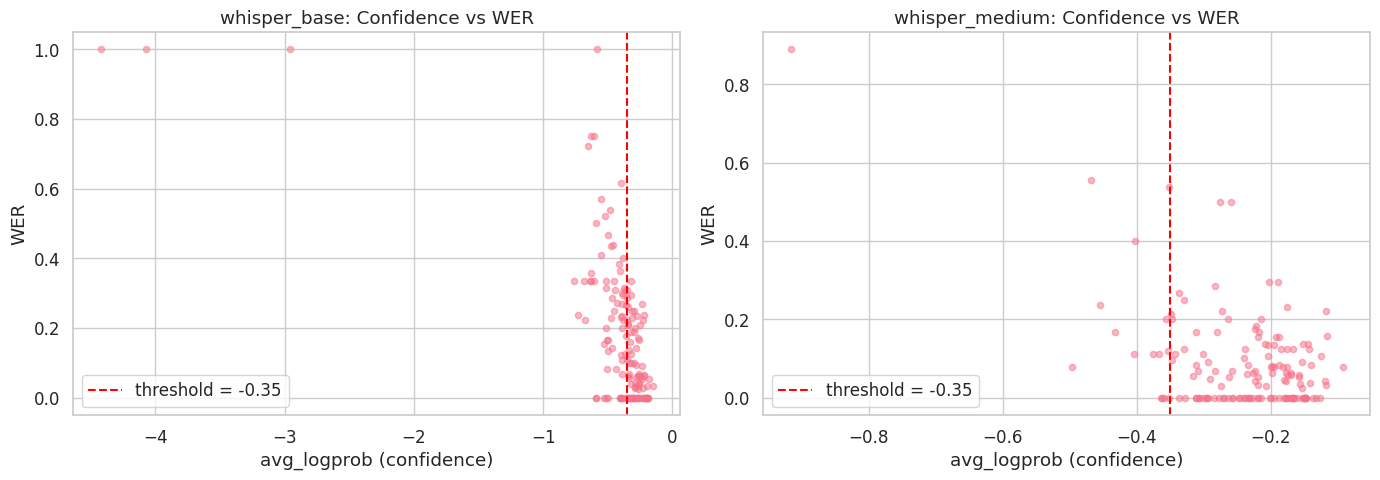


Threshold analysis:
 Threshold  Skip%   Skipped mean WER   Corrected mean WER
     -0.20  23.7%              0.053                0.165
     -0.25  39.0%              0.060                0.189
     -0.30  55.3%              0.069                0.224
     -0.35  70.7%              0.078                0.285
     -0.40  81.3%              0.089                0.354
     -0.50  90.0%              0.106                0.428


In [ ]:
# анализ: confidence vs WER на уровне сэмплов
# определяем оптимальный порог для confidence-aware

conf_rows = []
for key, exp in baselines_by_experiment.items():
    df = exp['df']
    if df['confidence'].notna().any():
        for _, row in df.iterrows():
            conf_rows.append({
                'experiment': key,
                'wer': row['wer'],
                'confidence': row['confidence'],
                'model': row['model'],
            })

conf_df = pd.DataFrame(conf_rows)
print(f'Samples with confidence: {len(conf_df)}')

# корреляция
corr = conf_df['confidence'].corr(conf_df['wer'])
print(f'Correlation (confidence vs WER): {corr:.3f}')

# график
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, model in enumerate(
    ['whisper_base', 'whisper_medium'],
):
    ax = axes[idx]
    data = conf_df[conf_df['model'] == model]
    ax.scatter(
        data['confidence'], data['wer'],
        alpha=0.5, s=20,
    )
    ax.set_xlabel('avg_logprob (confidence)')
    ax.set_ylabel('WER')
    ax.set_title(f'{model}: Confidence vs WER')
    ax.axvline(
        x=-0.35, color='red', ls='--',
        label='threshold = -0.35',
    )
    ax.legend()

plt.tight_layout()
plt.show()

# тест разных порогов
print('\nThreshold analysis:')
print(f'{"Threshold":>10} {"Skip%":>6} {"Skipped mean WER":>18} '
      f'{"Corrected mean WER":>20}')
for t in [-0.2, -0.25, -0.3, -0.35, -0.4, -0.5]:
    skip = conf_df[conf_df['confidence'] > t]
    corr_part = conf_df[conf_df['confidence'] <= t]
    skip_pct = len(skip) / len(conf_df) * 100
    skip_wer = skip['wer'].mean() if len(skip) > 0 else 0
    corr_wer = (
        corr_part['wer'].mean()
        if len(corr_part) > 0 else 0
    )
    print(f'{t:>10.2f} {skip_pct:>5.1f}% {skip_wer:>18.3f} '
          f'{corr_wer:>20.3f}')

## 6. Настройка LLM (HuggingFace Inference API)

HuggingFace Inference Providers - единый API к сотням моделей
через провайдеров (Cerebras, SambaNova, Novita и др.).
OpenAI-совместимый формат.

**Модели:**
- Qwen2.5 (7B)
- Llama 3.3 (70B)
- Qwen2.5 (72B)
- GPT-OSS 120B (120B MoE)
- Qwen3 235B (235B MoE)
- DeepSeek V3 (685B MoE)

In [ ]:
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    from getpass import getpass
    HF_TOKEN = getpass('Enter HF Token: ')

client = OpenAI(
    base_url='https://router.huggingface.co/v1',
    api_key=HF_TOKEN,
)
print('HuggingFace Inference client ready')

HuggingFace Inference client ready


In [ ]:
# быстрый тест - проверка работы клиента API
test_resp = client.chat.completions.create(
    model=config.llm_models[0]['id'],
    messages=[{'role': 'user', 'content': 'Say OK'}],
    max_tokens=5,
)
print(
    f"API test ({config.llm_models[0]['name']}): "
    f"{test_resp.choices[0].message.content}"
)

API test (Qwen2.5 7B): OK


## Промпты для LLM

In [ ]:
SYSTEM_PROMPT_EN = (
    'You are an expert at correcting automatic speech '
    'recognition (ASR) errors in English text.\n\n'
    'Rules:\n'
    '1. Fix only clear transcription errors\n'
    '2. Do NOT change meaning or style\n'
    '3. Do NOT add or remove punctuation\n'
    '4. Return ONLY the corrected text, nothing else'
)

SYSTEM_PROMPT_RU = (
    'Ты эксперт по исправлению ошибок автоматического '
    'распознавания речи (ASR) в русском тексте.\n\n'
    'Правила:\n'
    '1. Исправляй только явные ошибки транскрипции\n'
    '2. НЕ меняй смысл и стиль текста\n'
    '3. НЕ добавляй и не удаляй знаки препинания\n'
    '4. Верни ТОЛЬКО исправленный текст, ничего больше'
)

USER_TPL_EN = 'Fix ASR errors:\n\n{text}\n\nCorrected:'
USER_TPL_RU = (
    'Исправь ошибки ASR:\n\n{text}\n\nИсправленный текст:'
)

In [ ]:
# post-processing для LLM ответов.
# защита от галлюцинаций: обрезает длинные ответы,
# убирает декоративные префиксы и кавычки.

import re

CLEANUP_PREFIXES = [
    'Corrected:', 'Corrected text:',
    'Here is', "Here's",
    'The corrected', 'Fixed:',
    'The original text',
    'Исправленный текст:',
    'Исправлено:', 'Вот исправленный',
    'Since the original', 'It looks like',
]

TAIL_PATTERN = re.compile(
    r'\s*\((?:Note|Примечание|Текст не содержит)'
    r'[\s\S]*?\)\s*$',
    re.IGNORECASE,
)

REFUSAL_MARKERS = [
    'already correct',
    'appears correct',
    'appears to be correct',
    'no ASR errors',
    'no obvious ASR errors',
    'does not contain any',
    'не содержит ошибок',
    'исправления не требуются',
    'ошибок не обнаружено',
]


def clean_response(text: str, original: str) -> str:
    """Extract corrected text from LLM response."""
    if not text:
        return original

    text_lower = text.lower()
    for marker in REFUSAL_MARKERS:
        if marker in text_lower:
            return original

    text = TAIL_PATTERN.sub('', text).strip()

    if len(text) > len(original) * 1.5:
        first_line = text.split('\n')[0].strip()
        if first_line:
            text = first_line

    for prefix in CLEANUP_PREFIXES:
        if text.lower().startswith(prefix.lower()):
            text = text[len(prefix):].strip()
            break

    if (
        len(text) > 2
        and text[0] in '"\u201c'
        and text[-1] in '"\u201d'
    ):
        text = text[1:-1].strip()

    return text if text else original


## Функция коррекции с помощью LLM

In [ ]:
def correct_with_llm(
    text: str,
    model_id: str,
    language: str = 'en',
    temperature: float = 0.1,
    max_retries: int = 3,
) -> str:
    """Correct ASR text using HuggingFace Inference API."""

    if language == 'ru':
        sys_prompt = SYSTEM_PROMPT_RU
        usr_prompt = USER_TPL_RU.format(text=text)
    else:
        sys_prompt = SYSTEM_PROMPT_EN
        usr_prompt = USER_TPL_EN.format(text=text)

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model_id,
                messages=[
                    {'role': 'system', 'content': sys_prompt},
                    {'role': 'user', 'content': usr_prompt},
                ],
                temperature=temperature,
                max_tokens=500,
            )
            result = response.choices[0].message.content
            if result:
                return clean_response(
                    result.strip(), text,
                )
            return text
        except Exception as e:
            if '429' in str(e) or 'rate' in str(e).lower():
                wait = 2 ** attempt * 10
                logger.warning(
                    'Rate limited, waiting %ds...', wait,
                )
                time.sleep(wait)
            else:
                logger.error('LLM error: %s', e)
                return text

    logger.error('Max retries exceeded')
    return text

## Бенчмарк LLM коррекции

Для каждой модели прогоняем коррекцию на всех baseline (Whisper base, Whisper medium, GigaAM v2 CTC, GigaAM v2 RNNT, Wav2Vec2 XLS-R 1B RU, Wav2Vec2 XLS-R 1B EN).


In [ ]:
CONFIDENCE_THRESHOLD = -0.35


def run_correction(
    baseline_df: pd.DataFrame,
    model_id: str,
    model_name: str,
    language: str = 'en',
    confidence_threshold: float | None = None,
) -> pd.DataFrame:
    """
    Apply LLM correction to baseline samples.

    If confidence_threshold is set and confidence
    is available, skip samples above the threshold
    (high confidence = accurate transcription).
    """
    errors_df = baseline_df[
        baseline_df['wer'] > 0
    ].copy()
    if len(errors_df) == 0:
        return pd.DataFrame()

    results = []
    skipped = 0
    desc = f'{model_name} ({language})'

    for _, row in tqdm(
        errors_df.iterrows(),
        total=len(errors_df), desc=desc,
    ):
        # confidence-aware: пропуск там где высокий confidence
        conf = row.get('confidence', None)
        if (
            confidence_threshold is not None
            and conf is not None
            and conf > confidence_threshold
        ):
            corrected = row['hypothesis']
            skipped += 1
        else:
            corrected = correct_with_llm(
                row['hypothesis'], model_id,
                language=language,
            )

        new_wer = calculate_wer(
            row['reference'], corrected,
        )
        new_cer = calculate_cer(
            row['reference'], corrected,
        )

        results.append({
            'id': row['id'],
            'reference': row['reference'],
            'asr_output': row['hypothesis'],
            'llm_corrected': corrected,
            'wer_baseline': row['wer'],
            'wer_corrected': new_wer,
            'cer_baseline': row['cer'],
            'cer_corrected': new_cer,
            'wer_improved': row['wer'] > new_wer,
            'wer_degraded': row['wer'] < new_wer,
            'llm_model': model_name,
            'asr_model': row['model'],
            'language': language,
            'confidence': conf,
            'confidence_skipped': (
                confidence_threshold is not None
                and conf is not None
                and conf > confidence_threshold
            ),
        })

    print(
        f'  {model_name}: {skipped} skipped '
        f'/ {len(errors_df)} total '
        f'({skipped/len(errors_df)*100:.1f}%)'
    )
    return pd.DataFrame(results)

### Запуск бенчмарка

In [ ]:
# LLM correction через baselines_by_experiment
# С confidence-aware: Whisper пропускает высокоуверенные сэмплы

all_results_v2 = {}

print('=' * 70)
print(
    f'LLM correction: {len(config.llm_models)} models '
    f'x {len(baselines_by_experiment)} baselines '
    f'= {len(config.llm_models) * len(baselines_by_experiment)} '
    f'experiments'
)
print(f'Confidence threshold: {CONFIDENCE_THRESHOLD}')
print('=' * 70)

for model_info in config.llm_models:
    model_id = model_info['id']
    model_name = model_info['name']
    print(f'\n{"=" * 60}')
    print(
        f'  Benchmarking: {model_name} '
        f'({model_info["params"]}, {model_info["family"]})'
    )
    print(f'{"=" * 60}')

    for exp_key, exp in baselines_by_experiment.items():
        bl_df = exp['df']
        lang = exp['language']
        result_key = f'{model_name}__{exp_key}'

        # confidence-aware только для Whisper
        has_confidence = bl_df['confidence'].notna().any()
        threshold = (
            CONFIDENCE_THRESHOLD if has_confidence
            else None
        )

        result_df = run_correction(
            bl_df, model_id, model_name,
            language=lang,
            confidence_threshold=threshold,
        )
        all_results_v2[result_key] = result_df

        if len(result_df) > 0:
            bl_wer = result_df['wer_baseline'].mean()
            cr_wer = result_df['wer_corrected'].mean()
            change = (bl_wer - cr_wer) / bl_wer * 100
            skipped = result_df[
                'confidence_skipped'
            ].sum() if 'confidence_skipped' in result_df else 0
            print(
                f'  {exp_key}: {bl_wer:.2%} -> '
                f'{cr_wer:.2%} ({change:+.1f}%) '
                f'[skipped: {skipped}]'
            )
        else:
            print(f'  {exp_key}: no errors to correct')

print(
    f'\nBenchmark complete: '
    f'{len(all_results_v2)} result sets'
)

LLM correction: 6 models x 19 baselines = 114 experiments
Confidence threshold: -0.35

  Benchmarking: Qwen2.5 7B (7B, Alibaba)


Qwen2.5 7B (en):   0%|          | 0/14 [00:00<?, ?it/s]

  Qwen2.5 7B: 13 skipped / 14 total (92.9%)
  whisper_base__librispeech_test_clean: 8.10% -> 8.10% (+0.0%) [skipped: 13]


Qwen2.5 7B (en):   0%|          | 0/20 [00:00<?, ?it/s]

  Qwen2.5 7B: 12 skipped / 20 total (60.0%)
  whisper_base__librispeech_test_other: 15.62% -> 17.23% (-10.3%) [skipped: 12]


...

  DeepSeek V3: 0 skipped / 19 total (0.0%)
  wav2vec2_xlsr_1b_en__librispeech_test_clean: 9.68% -> 6.46% (+33.2%) [skipped: 0]


DeepSeek V3 (en):   0%|          | 0/14 [00:00<?, ?it/s]

  DeepSeek V3: 0 skipped / 14 total (0.0%)
  wav2vec2_xlsr_1b_en__librispeech_test_other: 12.91% -> 12.00% (+7.0%) [skipped: 0]


DeepSeek V3 (en):   0%|          | 0/28 [00:00<?, ?it/s]

  DeepSeek V3: 0 skipped / 28 total (0.0%)
  wav2vec2_xlsr_1b_en__fleurs_en: 16.87% -> 10.35% (+38.7%) [skipped: 0]

Benchmark complete: 114 result sets


In [ ]:
import pickle

# Сохранение всех результатов для безопасности
with open('/content/all_results_v2.pkl', 'wb') as f:
    pickle.dump(all_results_v2, f)

with open('/content/baselines_by_experiment.pkl', 'wb') as f:
    pickle.dump(baselines_by_experiment, f)

print(f'Saved {len(all_results_v2)} correction results')
print(f'Saved {len(baselines_by_experiment)} baselines')

Saved 114 correction results
Saved 19 baselines


In [ ]:
# построение единого датафрейма для анализа и визуализаций

def build_analysis_df(results_dict: dict) -> pd.DataFrame:
    """
    Form a single DataFrame for analysis and plots.

    Args:
        results_dict: Dict {'<llm>__<asr>__<dataset>': df}.

    Returns:
        DataFrame with lines for experiments and columns:
        LLM, ASR, Dataset, Language, Samples,
        Baseline WER, Corrected WER, WER Change (%),
        Improved, Degraded, Unchanged.
    """
    rows = []
    for key, df in results_dict.items():
        if len(df) == 0:
            continue

        # парсинг ключа: '<llm_name>__<asr_key>__<dataset_key>'
        parts = key.split('__')
        if len(parts) != 3:
            continue
        llm_name, asr_key, dataset_key = parts

        # берём метаданные из регистров
        asr_meta = asr_registry.get(asr_key, {})
        ds_meta = datasets_registry.get(dataset_key, {})

        bl_wer = df['wer_baseline'].mean()
        cr_wer = df['wer_corrected'].mean()
        change_pct = (
            (bl_wer - cr_wer) / bl_wer * 100
            if bl_wer > 0 else 0.0
        )

        rows.append({
            'LLM': llm_name,
            'ASR': asr_meta.get('display_name', asr_key),
            'ASR_key': asr_key,
            'Experiment': (
                f"{asr_meta.get('display_name', asr_key)} / "
                f"{ds_meta.get('display_name', dataset_key)}"
            ),
            'Dataset': ds_meta.get('display_name', dataset_key),
            'Dataset_key': dataset_key,
            'Language': ds_meta.get('language', '?'),
            'Samples': len(df),
            'Baseline WER': bl_wer,
            'Corrected WER': cr_wer,
            'WER Change (%)': change_pct,
            'Improved': int(df['wer_improved'].sum()),
            'Degraded': int(df['wer_degraded'].sum()),
            'Unchanged': int(
                (~df['wer_improved'] & ~df['wer_degraded']).sum()
            ),
        })

    return pd.DataFrame(rows)


analysis_df = build_analysis_df(all_results_v2)

print(f'Analysis DataFrame: {len(analysis_df)} rows')
print('=' * 70)
print(analysis_df[[
    'LLM', 'ASR', 'Dataset', 'Language',
    'Baseline WER', 'Corrected WER', 'WER Change (%)',
]].to_string(index=False))

print(analysis_df[[
    'LLM', 'ASR', 'Experiment', 'Language']].head(8).to_string(index=False))

Analysis DataFrame: 114 rows
          LLM                  ASR                Dataset Language  Baseline WER  Corrected WER  WER Change (%)
   Qwen2.5 7B         Whisper base LibriSpeech test-clean       en      0.081007       0.081007        0.000000
   Qwen2.5 7B         Whisper base LibriSpeech test-other       en      0.156211       0.172322      -10.313712
   Qwen2.5 7B         Whisper base         FLEURS English       en      0.202239       0.193051        4.543072
   Qwen2.5 7B         Whisper base         FLEURS Russian       ru      0.265635       0.272069       -2.422260
   Qwen2.5 7B         Whisper base        SOVA audiobooks       ru      0.456694       0.432886        5.213057
   Qwen2.5 7B       Whisper medium LibriSpeech test-clean       en      0.084372       0.084372        0.000000
   Qwen2.5 7B       Whisper medium LibriSpeech test-other       en      0.123710       0.123710        0.000000
   Qwen2.5 7B       Whisper medium         FLEURS English       en      0.0

In [ ]:
import os

os.makedirs('/content/results', exist_ok=True)

# CSV версия для чтения в Excel / таблицах
analysis_df.to_csv(
    '/content/results/analysis_df.csv',
    index=False,
    encoding='utf-8',
)

# Pickle версия для перезагрузки в Python
with open('/content/results/analysis_df.pkl', 'wb') as f:
    pickle.dump(analysis_df, f)

print(f'Saved analysis_df: {len(analysis_df)} rows')
print('Files:')
for f in os.listdir('/content/results'):
    size_kb = os.path.getsize(f'/content/results/{f}') / 1024
    print(f'  {f}: {size_kb:.1f} KB')

Saved analysis_df: 114 rows
Files:
  analysis_df.pkl: 18.5 KB
  analysis_df.csv: 20.2 KB


## Классификация ошибок по типам (Идея F)

Разбивка WER на три компонента через `jiwer.process_words()`:
- **Substitution** - слово заменено на другое (самая частая ошибка ASR)
- **Insertion** - лишнее слово добавлено
- **Deletion** - слово пропущено

Анализ проводится на двух уровнях:
1. **Baseline** - какие типы ошибок допускает каждая ASR
2. **После LLM-коррекции** - какие типы ошибок LLM исправляет, а какие создаёт

In [ ]:
# классификация ошибок: substitution / insertion / deletion
# через jiwer.process_words()


def classify_errors(
    reference: str, hypothesis: str,
) -> dict:
    """
    Classify word-level errors into S/I/D.

    """
    ref_norm = normalize_text(reference)
    hyp_norm = normalize_text(hypothesis)

    if not ref_norm:
        words = hyp_norm.split()
        return {
            'substitutions': 0,
            'insertions': len(words),
            'deletions': 0,
            'hits': 0,
            'ref_words': 0,
        }

    output = process_words(ref_norm, hyp_norm)
    return {
        'substitutions': output.substitutions,
        'insertions': output.insertions,
        'deletions': output.deletions,
        'hits': output.hits,
        'ref_words': (
            output.substitutions
            + output.deletions
            + output.hits
        ),
    }


In [ ]:
# быстрый тест
test = classify_errors(
    'the cat sat on the mat',
    'the cat sit on mat',
)
print(f'Test: {test}')

Test: {'substitutions': 1, 'insertions': 0, 'deletions': 1, 'hits': 4, 'ref_words': 6}


In [ ]:
# DataFrame с классификацией ошибок
# для каждого сэмпла в baseline и correction

error_rows = []

# Baseline errors (ASR без LLM)
for exp_key, exp in baselines_by_experiment.items():
    bl_df = exp['df']
    asr_display = exp['asr_display']
    ds_display = exp['dataset_display']
    lang = exp['language']

    for _, row in bl_df.iterrows():
        errs = classify_errors(
            row['reference'], row['hypothesis'],
        )
        error_rows.append({
            'Stage': 'Baseline',
            'ASR': asr_display,
            'Dataset': ds_display,
            'Language': lang,
            'LLM': 'none',
            'Experiment': f'{asr_display} / {ds_display}',
            **errs,
        })

# Correction errors (после LLM)
for key, df in all_results_v2.items():
    if len(df) == 0:
        continue
    parts = key.split('__')
    if len(parts) != 3:
        continue
    llm_name, asr_key, dataset_key = parts
    asr_meta = asr_registry.get(asr_key, {})
    ds_meta = datasets_registry.get(dataset_key, {})
    asr_display = asr_meta.get('display_name', asr_key)
    ds_display = ds_meta.get('display_name', dataset_key)

    for _, row in df.iterrows():
        errs = classify_errors(
            row['reference'], row['llm_corrected'],
        )
        error_rows.append({
            'Stage': 'Corrected',
            'ASR': asr_display,
            'Dataset': ds_display,
            'Language': ds_meta.get('language', '?'),
            'LLM': llm_name,
            'Experiment': f'{asr_display} / {ds_display}',
            **errs,
        })


In [ ]:
error_df = pd.DataFrame(error_rows)
print(f'Error classification: {len(error_df)} rows')
print(f'Columns: {list(error_df.columns)}')
print(
    f'\nBaseline rows: '
    f'{len(error_df[error_df["Stage"] == "Baseline"])}'
)
print(
    f'Corrected rows: '
    f'{len(error_df[error_df["Stage"] == "Corrected"])}'
)

Error classification: 2844 rows
Columns: ['Stage', 'ASR', 'Dataset', 'Language', 'LLM', 'Experiment', 'substitutions', 'insertions', 'deletions', 'hits', 'ref_words']

Baseline rows: 570
Corrected rows: 2274


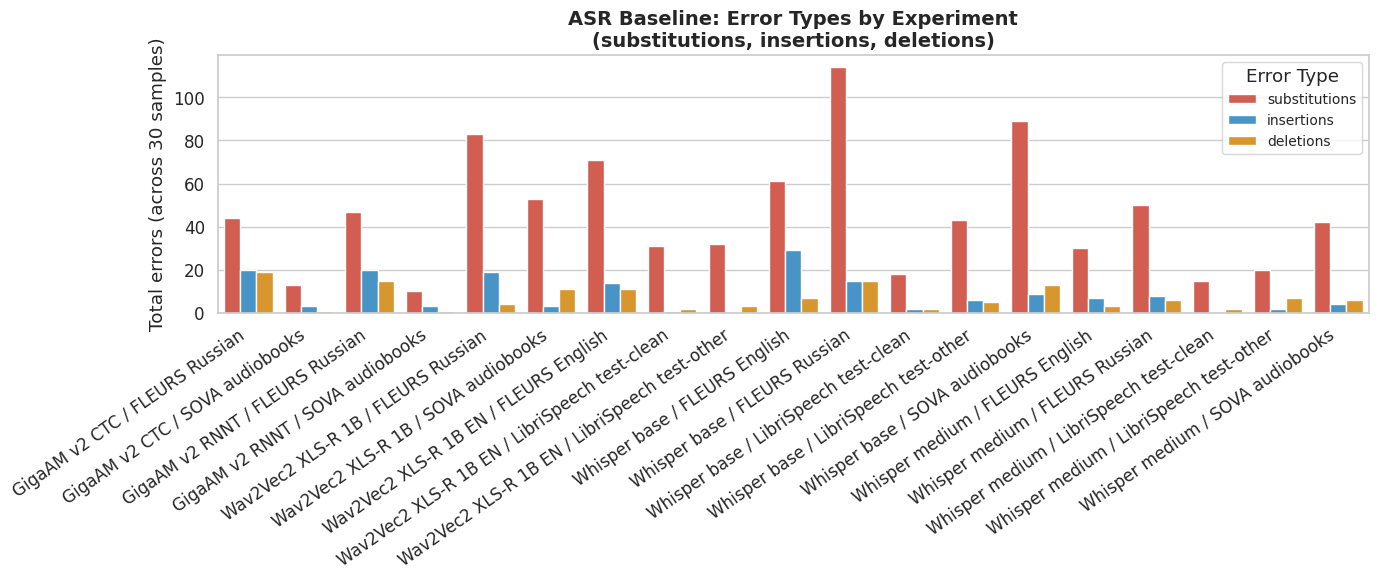

In [ ]:
# график 1F: Baseline error types по ASR-моделям
# показывает какие типы ошибок делает каждая ASR

baseline_errs = error_df[error_df['Stage'] == 'Baseline']

asr_error_agg = (
    baseline_errs
    .groupby(['ASR', 'Dataset'])[
        ['substitutions', 'insertions', 'deletions']
    ]
    .sum()
    .reset_index()
)
asr_error_agg['Experiment'] = (
    asr_error_agg['ASR'] + ' / ' + asr_error_agg['Dataset']
)

asr_melt = asr_error_agg.melt(
    id_vars='Experiment',
    value_vars=['substitutions', 'insertions', 'deletions'],
    var_name='Error Type',
    value_name='Count',
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=asr_melt,
    x='Experiment',
    y='Count',
    hue='Error Type',
    ax=ax,
    palette=['#e74c3c', '#3498db', '#f39c12'],
    edgecolor='white',
)
ax.set_title(
    'ASR Baseline: Error Types by Experiment\n'
    '(substitutions, insertions, deletions)',
    fontsize=14, fontweight='bold',
)
ax.set_xlabel('')
ax.set_ylabel('Total errors (across 30 samples)')
ax.legend(title='Error Type', fontsize=10)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

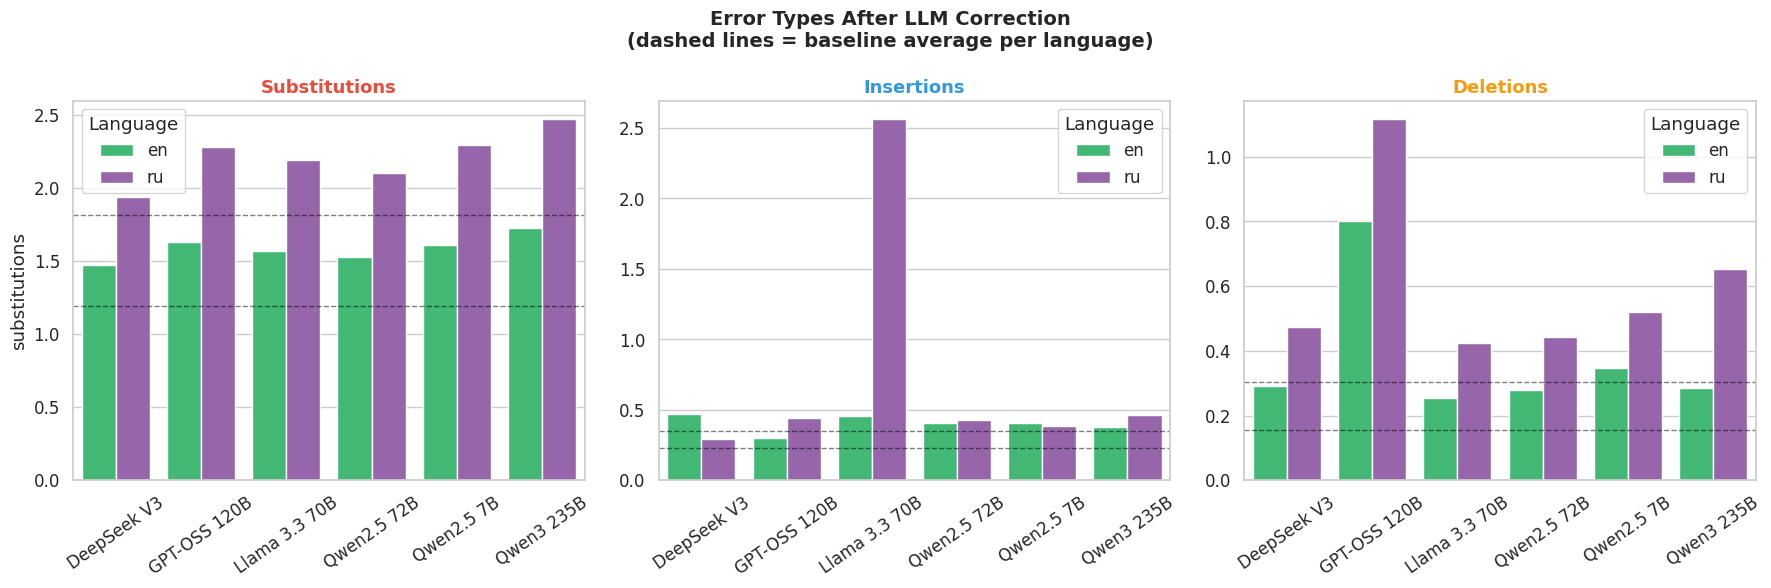

In [ ]:
# график 2F: Error type change after LLM correction
# для каждой LLM: сколько S/I/D в baseline vs corrected

# агрегируем baseline ошибки (одинаковые для всех LLM)
bl_agg = (
    baseline_errs
    .groupby('Language')[
        ['substitutions', 'insertions', 'deletions']
    ]
    .mean()
    .reset_index()
)

# агрегируем corrected ошибки по LLM
corrected_errs = error_df[error_df['Stage'] == 'Corrected']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
error_types = ['substitutions', 'insertions', 'deletions']
colors = ['#e74c3c', '#3498db', '#f39c12']

for idx, etype in enumerate(error_types):
    ax = axes[idx]

    # среднее по (LLM, Language)
    llm_agg = (
        corrected_errs
        .groupby(['LLM', 'Language'])[etype]
        .mean()
        .reset_index()
    )

    sns.barplot(
        data=llm_agg,
        x='LLM',
        y=etype,
        hue='Language',
        ax=ax,
        palette=['#2ecc71', '#9b59b6'],
        edgecolor='white',
    )

    # baseline reference lines
    for _, bl_row in bl_agg.iterrows():
        lang = bl_row['Language']
        val = bl_row[etype]
        ax.axhline(
            y=val, color='black',
            ls='--', lw=1, alpha=0.5,
        )

    ax.set_title(
        etype.capitalize(),
        fontsize=13, fontweight='bold',
        color=colors[idx],
    )
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
    if idx > 0:
        ax.set_ylabel('')

fig.suptitle(
    'Error Types After LLM Correction\n'
    '(dashed lines = baseline average per language)',
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.show()

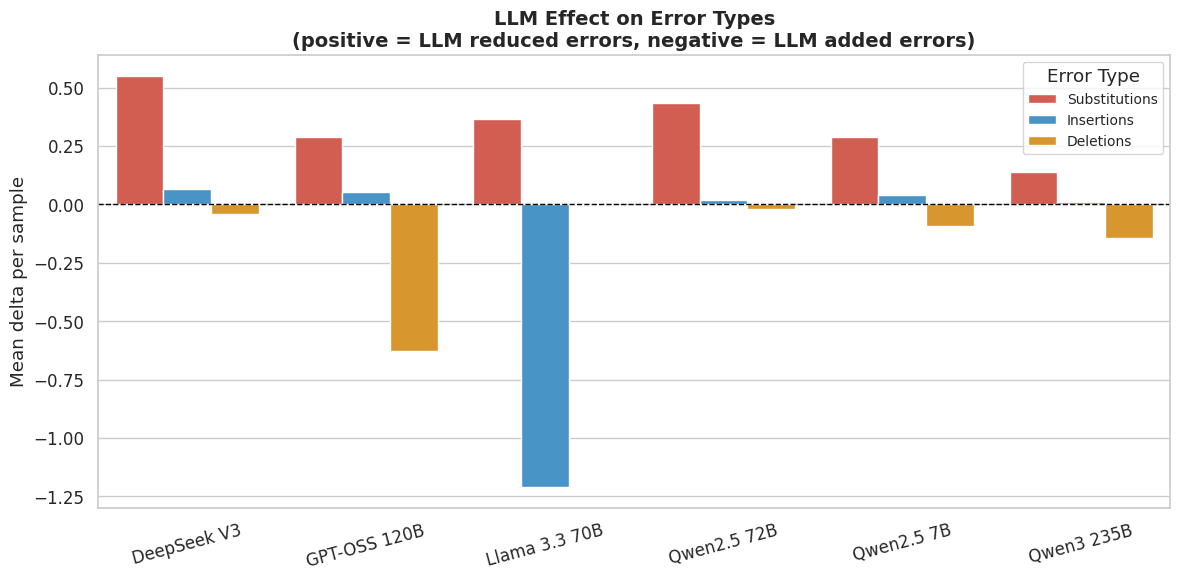

In [ ]:
# график 3F: Delta error counts (baseline - corrected)
# положительные = LLM уменьшила кол-во ошибок этого типа

delta_rows = []
for key, df in all_results_v2.items():
    if len(df) == 0:
        continue
    parts = key.split('__')
    if len(parts) != 3:
        continue
    llm_name, asr_key, dataset_key = parts
    ds_meta = datasets_registry.get(dataset_key, {})

    for _, row in df.iterrows():
        bl_errs = classify_errors(
            row['reference'], row['asr_output'],
        )
        cr_errs = classify_errors(
            row['reference'], row['llm_corrected'],
        )
        delta_rows.append({
            'LLM': llm_name,
            'Language': ds_meta.get('language', '?'),
            'delta_sub': (
                bl_errs['substitutions']
                - cr_errs['substitutions']
            ),
            'delta_ins': (
                bl_errs['insertions']
                - cr_errs['insertions']
            ),
            'delta_del': (
                bl_errs['deletions']
                - cr_errs['deletions']
            ),
        })

delta_df = pd.DataFrame(delta_rows)

# агрегация по LLM
delta_agg = (
    delta_df
    .groupby('LLM')[['delta_sub', 'delta_ins', 'delta_del']]
    .mean()
    .reset_index()
)
delta_agg.columns = [
    'LLM', 'Substitutions', 'Insertions', 'Deletions',
]

delta_melt = delta_agg.melt(
    id_vars='LLM',
    var_name='Error Type',
    value_name='Mean Delta (fewer = better)',
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=delta_melt,
    x='LLM',
    y='Mean Delta (fewer = better)',
    hue='Error Type',
    ax=ax,
    palette=['#e74c3c', '#3498db', '#f39c12'],
    edgecolor='white',
)
ax.axhline(y=0, color='black', ls='--', lw=1)
ax.set_title(
    'LLM Effect on Error Types\n'
    '(positive = LLM reduced errors, '
    'negative = LLM added errors)',
    fontsize=14, fontweight='bold',
)
ax.set_xlabel('')
ax.set_ylabel('Mean delta per sample')
ax.legend(title='Error Type', fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# сводная таблица: средние S/I/D по LLM и Stage

summary = (
    error_df
    .groupby(['Stage', 'LLM'])[
        ['substitutions', 'insertions', 'deletions']
    ]
    .mean()
    .round(2)
    .reset_index()
)

print('Error Type Summary (mean per sample):')
print(summary.to_string(index=False))

Error Type Summary (mean per sample):
    Stage           LLM  substitutions  insertions  deletions
 Baseline          none           1.52        0.29       0.23
Corrected   DeepSeek V3           1.73        0.37       0.39
Corrected  GPT-OSS 120B           1.99        0.38       0.98
Corrected Llama 3.3 70B           1.92        1.65       0.35
Corrected   Qwen2.5 72B           1.85        0.42       0.37
Corrected    Qwen2.5 7B           1.99        0.40       0.44
Corrected    Qwen3 235B           2.15        0.42       0.49


### Выводы по классификации ошибок (Идея F)

**1. ASR-модели ошибаются преимущественно через substitution.**
В baseline 75% ошибок составляют замены слов (1.52 из 2.04 total). Insertions (0.29) и deletions (0.23) - 14% и 11% соответственно.

**2. LLM-коррекция не уменьшает substitutions в среднем.**
Все 6 LLM показывают средний substitution count выше baseline (1.73-2.15 vs 1.52). LLM иногда заменяет правильные слова синонимами.

**3. Llama 3.3 70B - рекордсмен по insertions.**
1.65 insertions на сэмпл (baseline 0.29) - пятикратное увеличение. Коррелирует с аномалиями Llama на SOVA audiobooks (-379.9%) и Wav2Vec2 SOVA (-211.6%), где модель переводит русский текст на английский.

**4. GPT-OSS 120B удаляет слова.**
Deletions 0.98 (baseline 0.23) - четырёхкратное увеличение. Qwen3 235B на втором месте с 0.49.

**5. DeepSeek V3 - наиболее сбалансированная модель.**
Минимальное увеличение ошибок: 1.73/0.37/0.39 (baseline 1.52/0.29/0.23). Qwen2.5 72B на втором месте: 1.85/0.42/0.37.

**6. Данные мотивируют фонетическую фильтрацию.**
31.5% всех substitutions в LLM-коррекции (548 из 1738) оказываются фонетически далёкими от оригинала ASR.

## Визуализации (Графики)

Все графики строятся из единого DataFrame `analysis_df`, который
содержит все эксперименты (LLM × ASR × Dataset) с метаданными.

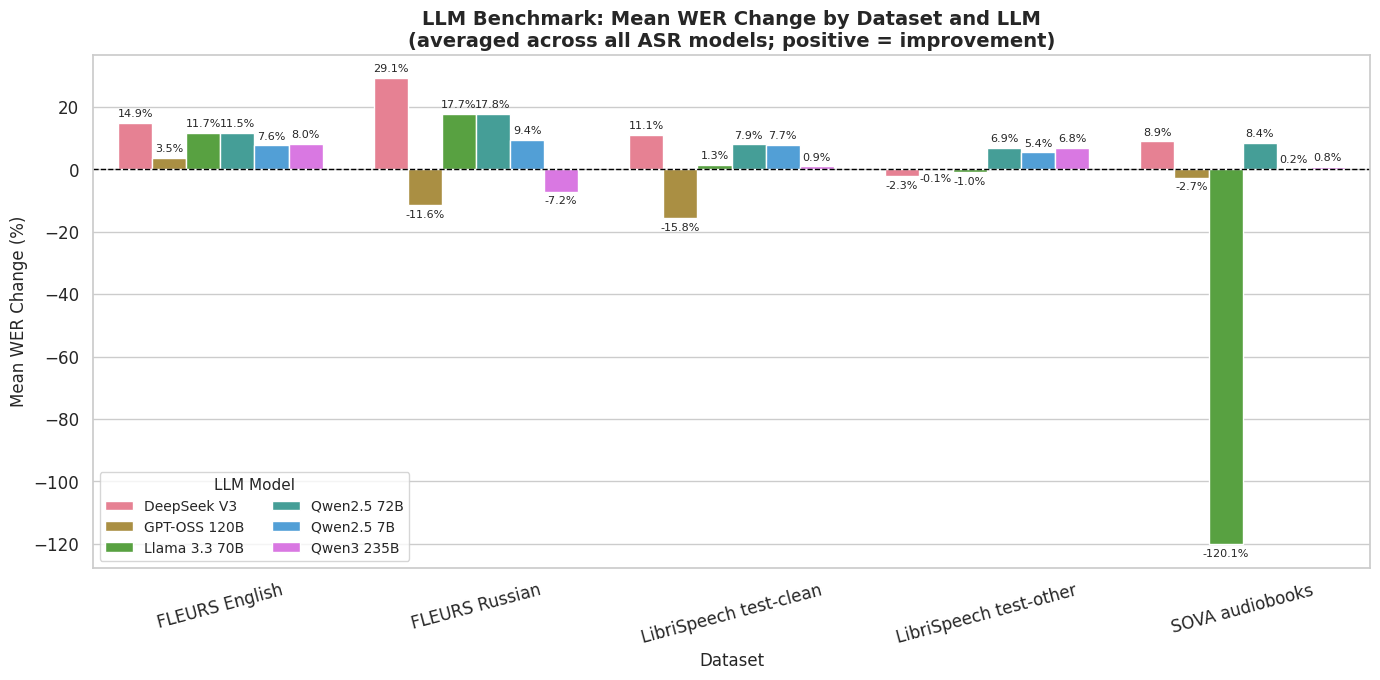

In [ ]:
# график WER change by LLM x Dataset

agg_by_dataset = (
    analysis_df
    .groupby(['LLM', 'Dataset'])['WER Change (%)']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(
    data=agg_by_dataset,
    x='Dataset',
    y='WER Change (%)',
    hue='LLM',
    ax=ax,
    edgecolor='white',
)
ax.axhline(y=0, color='black', linewidth=1, ls='--')
ax.set_title(
    'LLM Benchmark: Mean WER Change by Dataset and LLM\n'
    '(averaged across all ASR models; '
    'positive = improvement)',
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('Mean WER Change (%)', fontsize=12)
ax.legend(
    title='LLM Model',
    fontsize=10,
    title_fontsize=11,
    loc='best',
    ncol=2,
)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        fontsize=8,
        padding=3,
    )
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



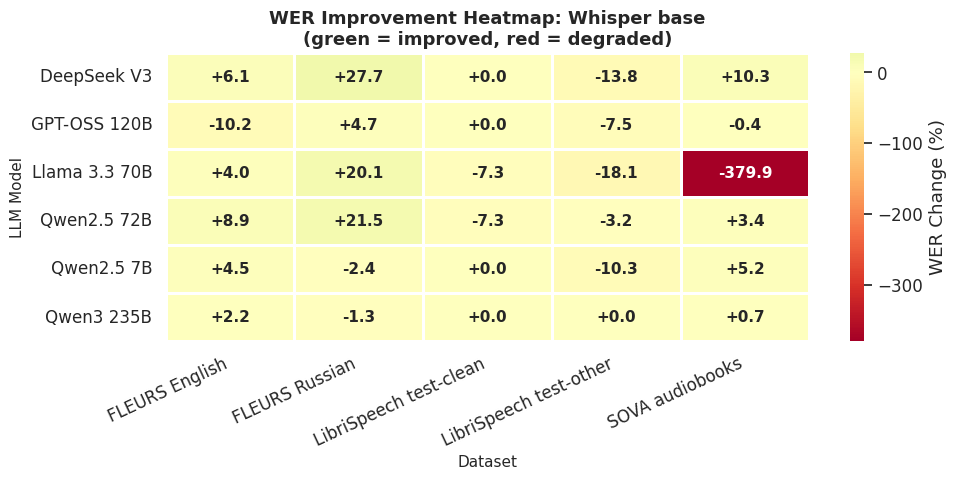

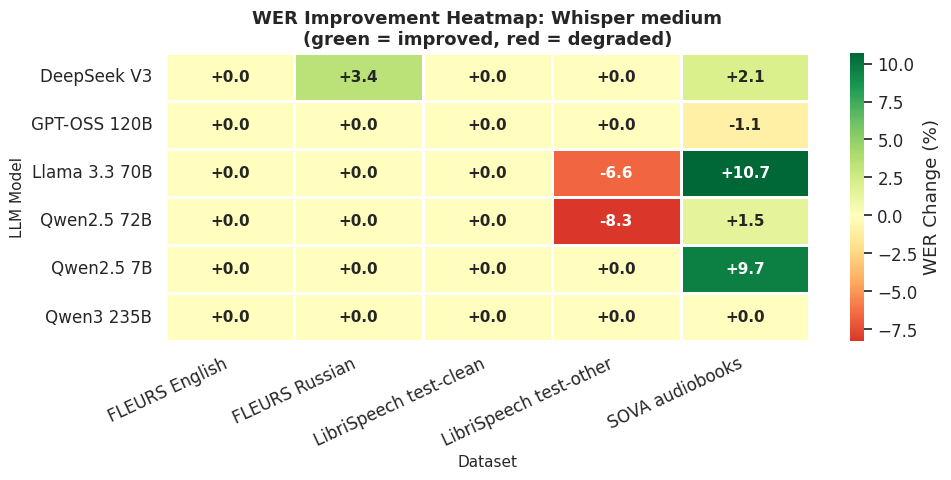

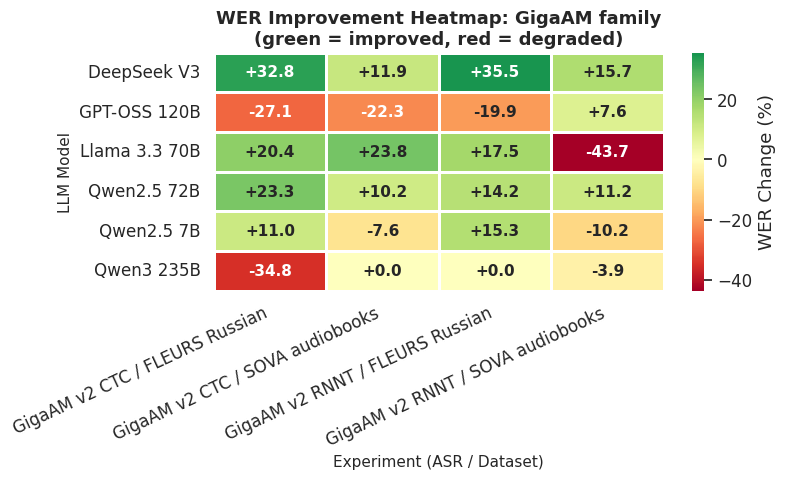

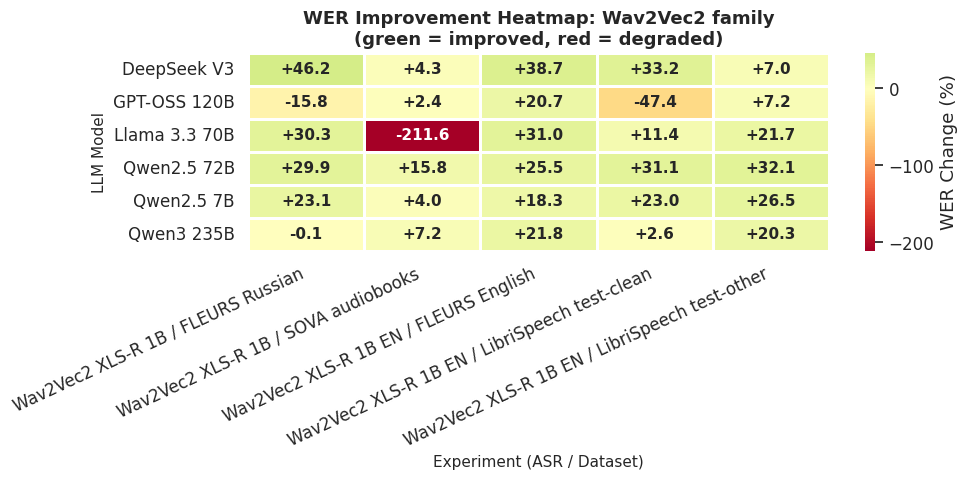

In [ ]:
# график: WER Change heatmaps разбитые по ASR-семействам.

asr_groups = {
    'Whisper base': ['Whisper base'],
    'Whisper medium': ['Whisper medium'],
    'GigaAM family': ['GigaAM v2 CTC', 'GigaAM v2 RNNT'],
    'Wav2Vec2 family': [
        'Wav2Vec2 XLS-R 1B',
        'Wav2Vec2 XLS-R 1B EN',
    ],
}

for group_name, asr_list in asr_groups.items():
    group_df = analysis_df[analysis_df['ASR'].isin(asr_list)]

    if len(group_df) == 0:
        continue

    if len(asr_list) == 1:
        pivot = group_df.pivot(
            index='LLM',
            columns='Dataset',
            values='WER Change (%)',
        )
        xlabel_text = 'Dataset'
    else:
        pivot = group_df.pivot(
            index='LLM',
            columns='Experiment',
            values='WER Change (%)',
        )
        xlabel_text = 'Experiment (ASR / Dataset)'

    n_cols = len(pivot.columns)
    fig, ax = plt.subplots(figsize=(max(8, n_cols * 2), 5))
    sns.heatmap(
        pivot,
        annot=True,
        fmt='+.1f',
        cmap='RdYlGn',
        center=0,
        linewidths=2,
        linecolor='white',
        ax=ax,
        annot_kws={'fontsize': 11, 'fontweight': 'bold'},
        cbar_kws={'label': 'WER Change (%)'},
    )
    ax.set_title(
        f'WER Improvement Heatmap: {group_name}\n'
        '(green = improved, red = degraded)',
        fontsize=13,
        fontweight='bold',
    )
    ax.set_xlabel(xlabel_text, fontsize=11)
    ax.set_ylabel('LLM Model', fontsize=11)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

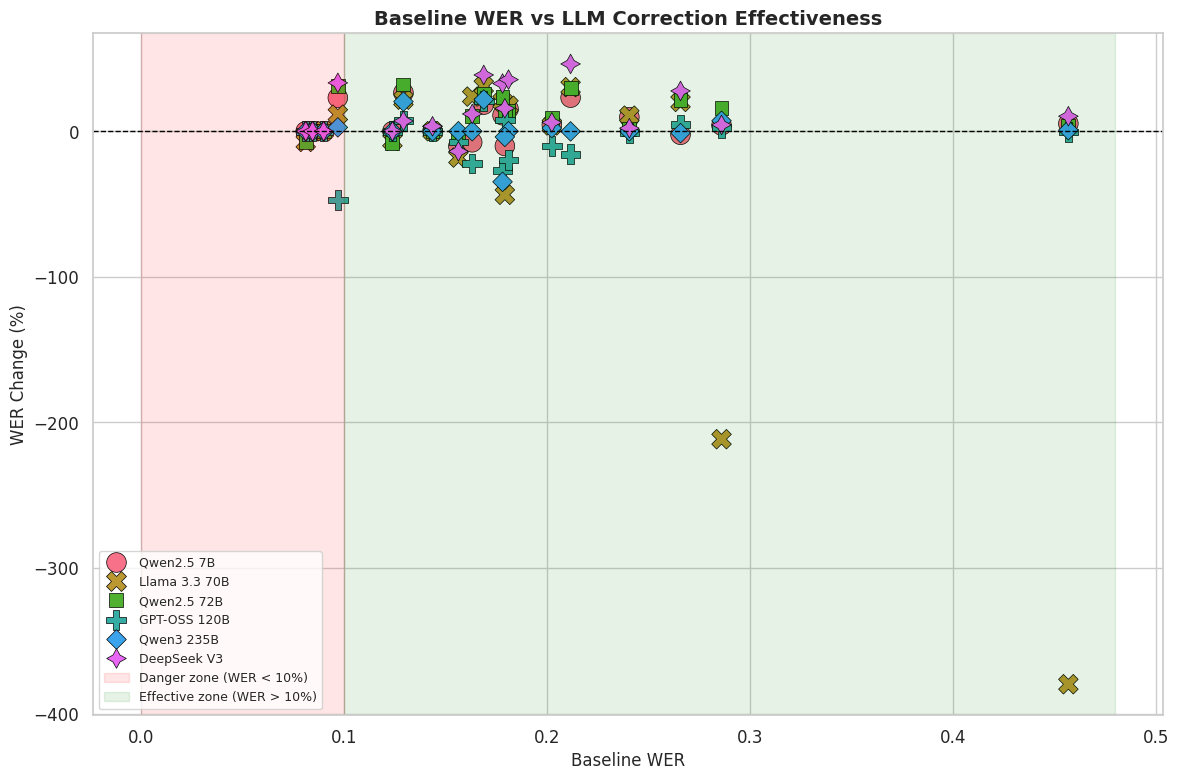

In [ ]:
# график: Baseline WER vs LLM Effectiveness

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=analysis_df,
    x='Baseline WER',
    y='WER Change (%)',
    hue='LLM',
    style='LLM',
    s=200,
    ax=ax,
    edgecolor='black',
    linewidth=0.5,
)

ax.axhline(y=0, color='black', ls='--', lw=1)
ax.axvspan(
    0, 0.10,
    alpha=0.1,
    color='red',
    label='Danger zone (WER < 10%)',
)
ax.axvspan(
    0.10, ax.get_xlim()[1],
    alpha=0.1,
    color='green',
    label='Effective zone (WER > 10%)',
)
ax.set_title(
    'Baseline WER vs LLM Correction Effectiveness',
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel('Baseline WER', fontsize=12)
ax.set_ylabel('WER Change (%)', fontsize=12)
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()



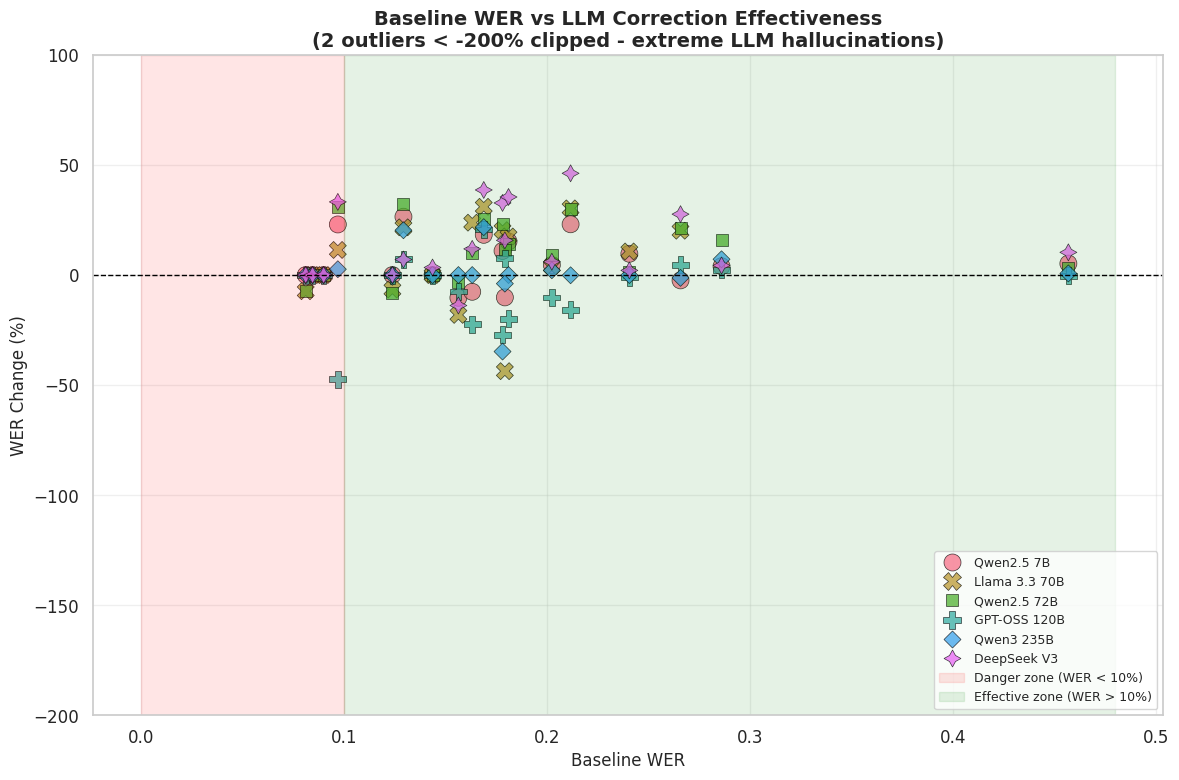

In [ ]:
# график: Baseline WER vs LLM Effectiveness
# Ось Y ограничена диапазоном -200..+100


OUTLIER_THRESHOLD_MIN = -200
n_outliers = int(
    (analysis_df['WER Change (%)'] < OUTLIER_THRESHOLD_MIN).sum()
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=analysis_df,
    x='Baseline WER',
    y='WER Change (%)',
    hue='LLM',
    style='LLM',
    s=150,
    ax=ax,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.75,
)
ax.axhline(y=0, color='black', ls='--', lw=1)
ax.axvspan(
    0, 0.10,
    alpha=0.1,
    color='red',
    label='Danger zone (WER < 10%)',
)
ax.axvspan(
    0.10, ax.get_xlim()[1],
    alpha=0.1,
    color='green',
    label='Effective zone (WER > 10%)',
)
ax.set_ylim(OUTLIER_THRESHOLD_MIN, 100)
title = (
    'Baseline WER vs LLM Correction Effectiveness'
)
if n_outliers > 0:
    title += (
        f'\n({n_outliers} outliers < '
        f'{OUTLIER_THRESHOLD_MIN}% clipped - '
        'extreme LLM hallucinations)'
    )
ax.set_title(title, fontsize=14, fontweight='bold')
ax.set_xlabel('Baseline WER', fontsize=12)
ax.set_ylabel('WER Change (%)', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

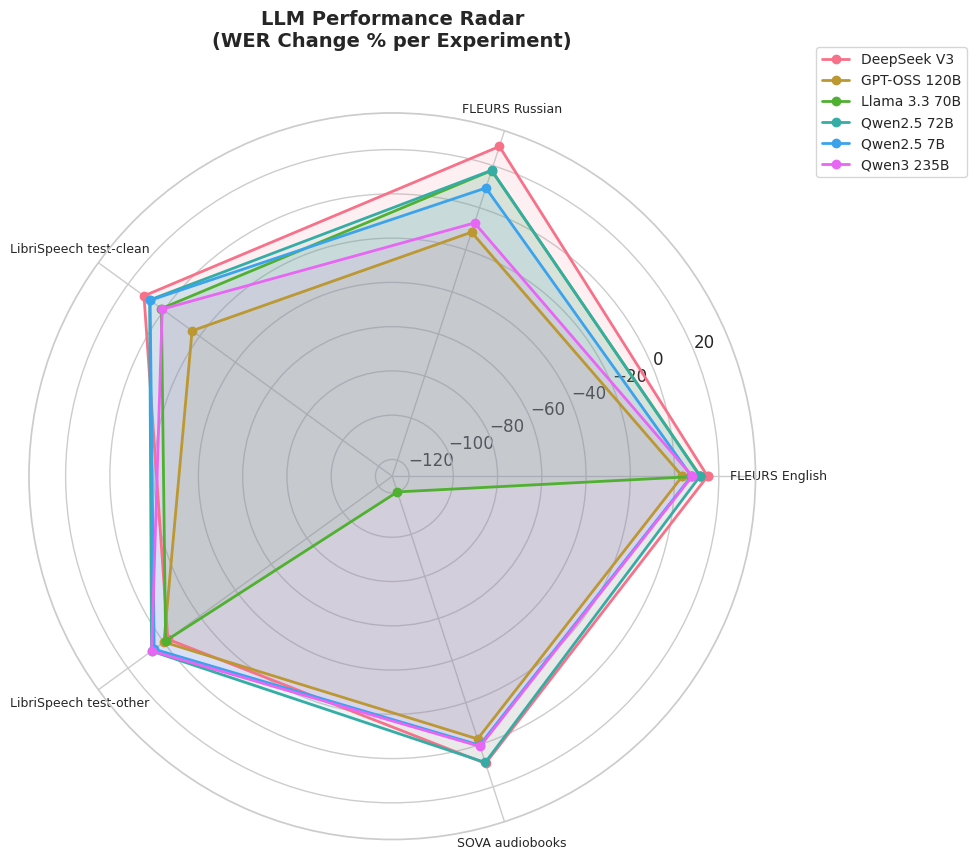

In [ ]:
# график: LLM Radar by Dataset

radar_data = (
    analysis_df
    .groupby(['LLM', 'Dataset'])['WER Change (%)']
    .mean()
    .reset_index()
)
pivot_radar = radar_data.pivot(
    index='LLM',
    columns='Dataset',
    values='WER Change (%)',
)

categories = list(pivot_radar.columns)
n_cats = len(categories)
angles = [n / float(n_cats) * 2 * pi for n in range(n_cats)]
angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw=dict(polar=True),
)
colors = sns.color_palette('husl', len(pivot_radar))

for i, (llm, row) in enumerate(pivot_radar.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(
        angles, values, 'o-',
        linewidth=2, label=llm, color=colors[i],
    )
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_title(
    'LLM Performance Radar\n(WER Change % per Experiment)',
    fontsize=14,
    fontweight='bold',
    y=1.08,
)
ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.3, 1.1),
    fontsize=10,
)
plt.tight_layout()
plt.show()


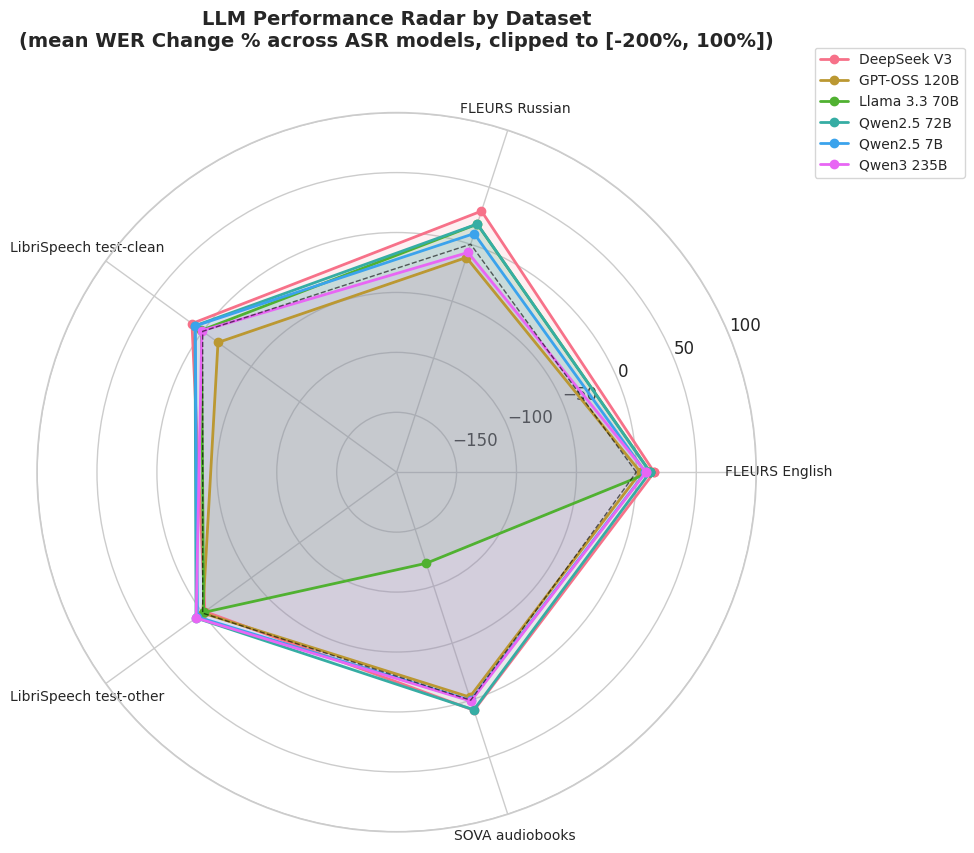

In [ ]:
# график: LLM Radar by Dataset
# радиус обрезан до [-200, +100]

radar_data = (
    analysis_df
    .groupby(['LLM', 'Dataset'])['WER Change (%)']
    .mean()
    .reset_index()
)

RADAR_MIN = -200
RADAR_MAX = 100
radar_data['WER Change (clipped)'] = (
    radar_data['WER Change (%)'].clip(
        lower=RADAR_MIN, upper=RADAR_MAX,
    )
)

pivot_radar = radar_data.pivot(
    index='LLM',
    columns='Dataset',
    values='WER Change (clipped)',
)
categories = list(pivot_radar.columns)
n_cats = len(categories)
angles = [n / float(n_cats) * 2 * pi for n in range(n_cats)]
angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw=dict(polar=True),
)
colors = sns.color_palette('husl', len(pivot_radar))

for i, (llm, row) in enumerate(pivot_radar.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(
        angles, values, 'o-',
        linewidth=2, label=llm, color=colors[i],
    )
    ax.fill(angles, values, alpha=0.1, color=colors[i])

# Ось 0 — пунктирная для визуального «нулевого круга»
ax.plot(
    angles, [0] * len(angles),
    color='black', linewidth=1, linestyle='--', alpha=0.6,
)

ax.set_ylim(RADAR_MIN, RADAR_MAX)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_title(
    'LLM Performance Radar by Dataset\n'
    '(mean WER Change % across ASR models, '
    f'clipped to [{RADAR_MIN}%, {RADAR_MAX}%])',
    fontsize=14,
    fontweight='bold',
    y=1.08,
)
ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.3, 1.1),
    fontsize=10,
)
plt.tight_layout()
plt.show()

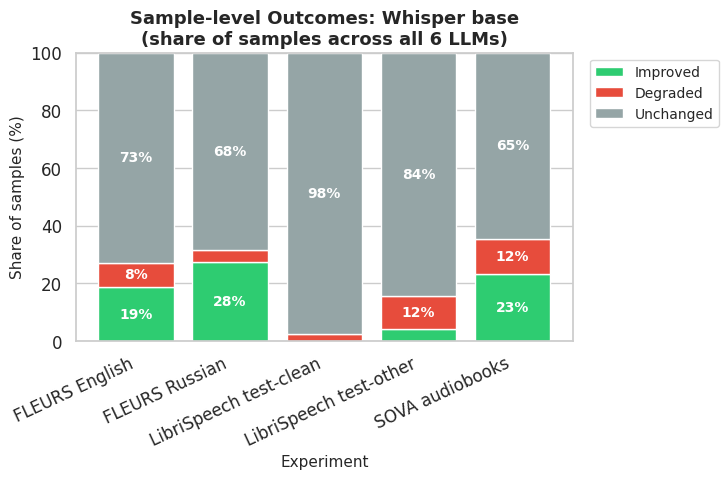

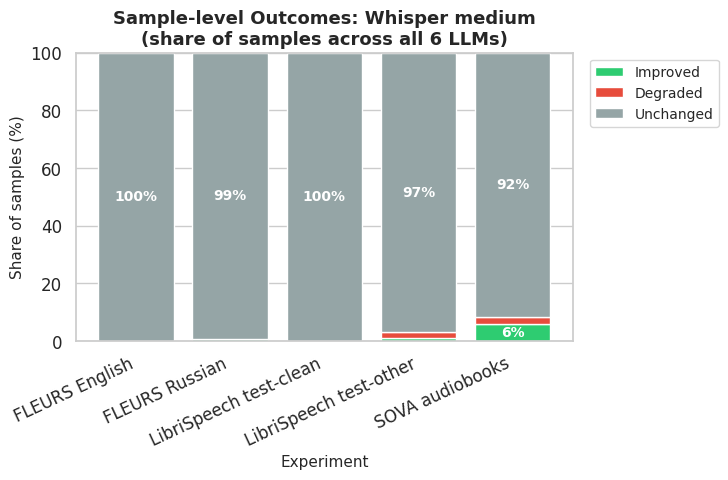

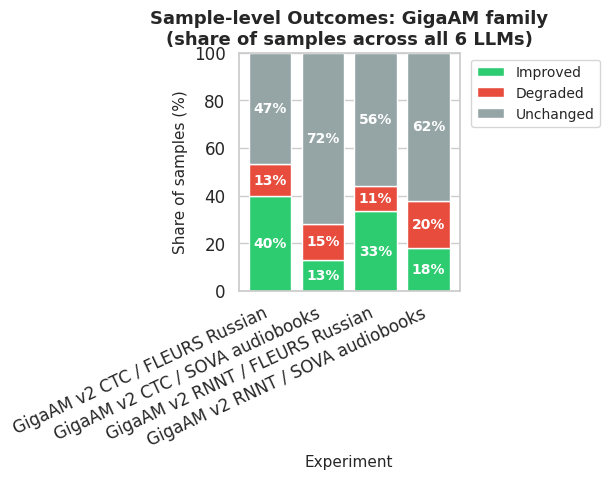

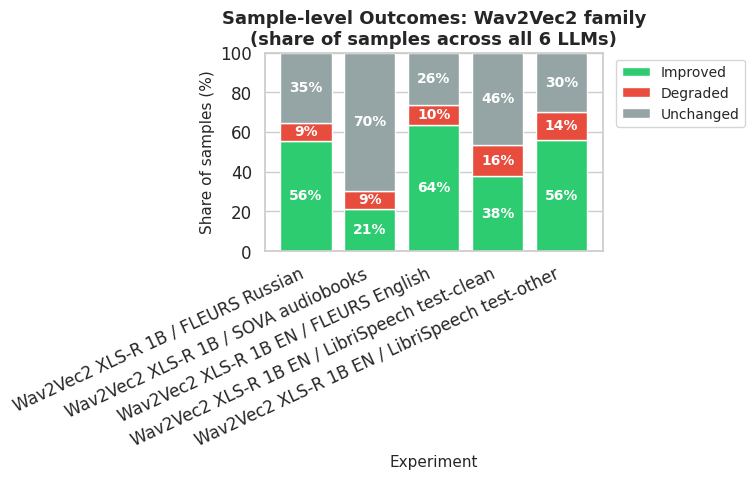

In [ ]:
# график: Sample-level результаты по ASR-семействам.
# доли improved/degraded/unchanged
# среди всех сэмплов × всех LLM.

asr_groups = {
    'Whisper base': ['Whisper base'],
    'Whisper medium': ['Whisper medium'],
    'GigaAM family': ['GigaAM v2 CTC', 'GigaAM v2 RNNT'],
    'Wav2Vec2 family': [
        'Wav2Vec2 XLS-R 1B',
        'Wav2Vec2 XLS-R 1B EN',
    ],
}
colors = {
    'Improved': '#2ecc71',
    'Degraded': '#e74c3c',
    'Unchanged': '#95a5a6',
}

for group_name, asr_list in asr_groups.items():
    group_df = analysis_df[analysis_df['ASR'].isin(asr_list)]

    if len(group_df) == 0:
        continue

    if len(asr_list) == 1:
        group_df = group_df.assign(X=group_df['Dataset'])
    else:
        group_df = group_df.assign(
            X=group_df['ASR'] + ' / ' + group_df['Dataset']
        )

    counts = group_df.groupby('X').agg({
        'Improved': 'sum',
        'Degraded': 'sum',
        'Unchanged': 'sum',
    }).reset_index()

    # нормализуем: каждый столбик = 100%
    totals = (
        counts['Improved']
        + counts['Degraded']
        + counts['Unchanged']
    )
    counts['Improved %'] = counts['Improved'] / totals * 100
    counts['Degraded %'] = counts['Degraded'] / totals * 100
    counts['Unchanged %'] = counts['Unchanged'] / totals * 100

    fig, ax = plt.subplots(
        figsize=(max(6, len(counts) * 1.5), 5),
    )
    bottom = [0] * len(counts)
    for category in ['Improved', 'Degraded', 'Unchanged']:
        col_pct = f'{category} %'
        values = counts[col_pct].values
        ax.bar(
            counts['X'],
            values,
            bottom=bottom,
            label=category,
            color=colors[category],
            edgecolor='white',
        )
        # надпись только если доля > 5%
        for i, v in enumerate(values):
            if v > 5:
                ax.text(
                    i, bottom[i] + v / 2,
                    f'{v:.0f}%',
                    ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white',
                )
        bottom = [b + v for b, v in zip(bottom, values)]

    ax.set_title(
        f'Sample-level Outcomes: {group_name}\n'
        '(share of samples across all 6 LLMs)',
        fontsize=13,
        fontweight='bold',
    )
    ax.set_xlabel('Experiment', fontsize=11)
    ax.set_ylabel('Share of samples (%)', fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(
        fontsize=10,
        loc='upper left',
        bbox_to_anchor=(1.02, 1.0),
    )
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

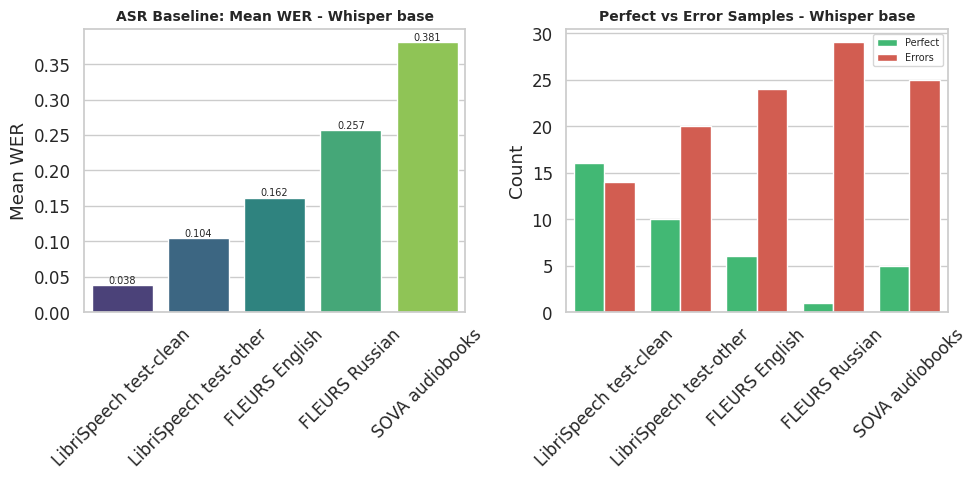

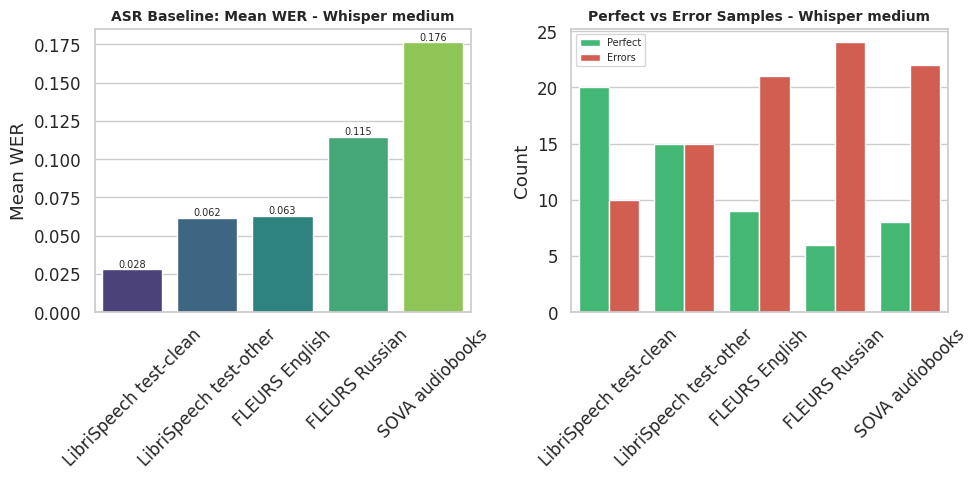

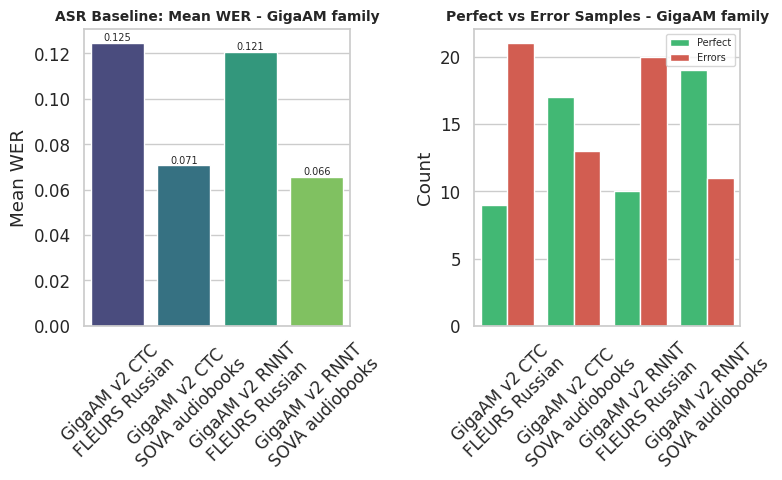

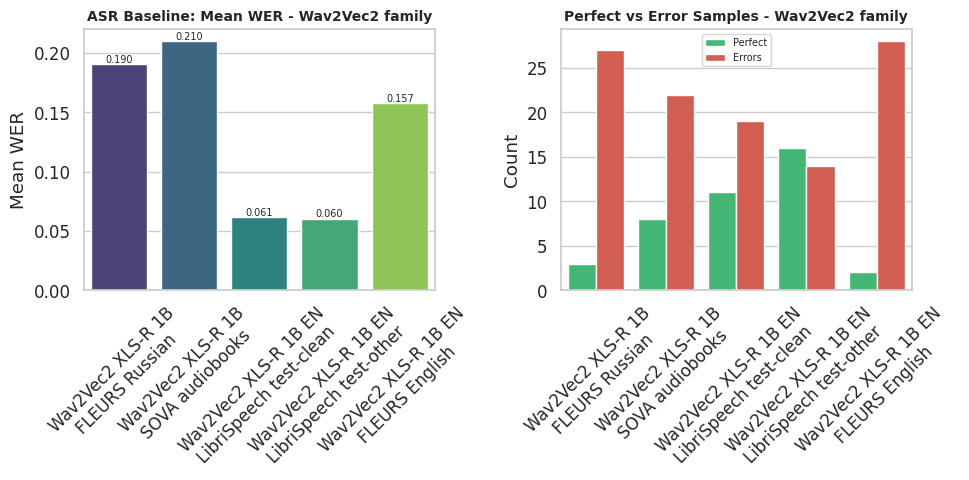

In [ ]:
# график: ASR Baseline WER Comparison (без участия LLM)
# по ASR-семействам.

baseline_rows = []
for exp_key, exp in baselines_by_experiment.items():
    mean_wer = exp['df']['wer'].mean()
    errors = int((exp['df']['wer'] > 0).sum())
    perfect = int((exp['df']['wer'] == 0).sum())
    baseline_rows.append({
        'Experiment': exp_key,
        'ASR': exp['asr_display'],
        'Dataset': exp['dataset_display'],
        'Language': exp['language'],
        'Mean WER': mean_wer,
        'Errors': errors,
        'Perfect': perfect,
    })
baseline_view = pd.DataFrame(baseline_rows)

asr_groups = {
    'Whisper base': ['Whisper base'],
    'Whisper medium': ['Whisper medium'],
    'GigaAM family': ['GigaAM v2 CTC', 'GigaAM v2 RNNT'],
    'Wav2Vec2 family': [
        'Wav2Vec2 XLS-R 1B',
        'Wav2Vec2 XLS-R 1B EN',
    ],
}

for group_name, asr_list in asr_groups.items():
    group_df = baseline_view[
        baseline_view['ASR'].isin(asr_list)
    ]
    if len(group_df) == 0:
        continue

    if len(asr_list) == 1:
        group_df = group_df.assign(X=group_df['Dataset'])
    else:
        group_df = group_df.assign(
            X=group_df['ASR'] + '\n' + group_df['Dataset']
        )

    fig, axes = plt.subplots(
        1, 2,
        figsize=(max(8, len(group_df) * 2), 5),
    )

    # графики слева: mean WER
    sns.barplot(
        data=group_df,
        x='X',
        y='Mean WER',
        hue='X',
        ax=axes[0],
        palette='viridis',
        edgecolor='white',
        legend=False,
        errorbar=None,
    )
    axes[0].set_title(
        f'ASR Baseline: Mean WER - {group_name}',
        fontsize=10,
        fontweight='bold',
    )
    for container in axes[0].containers:
        axes[0].bar_label(
            container, fmt='%.3f', fontsize=7,
        )
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].set_xlabel('')

    # графики справа: perfect vs errors
    bl_melt = group_df.melt(
        id_vars='X',
        value_vars=['Perfect', 'Errors'],
        var_name='Type',
        value_name='Count',
    )
    sns.barplot(
        data=bl_melt,
        x='X',
        y='Count',
        hue='Type',
        ax=axes[1],
        palette=['#2ecc71', '#e74c3c'],
        edgecolor='white',
        errorbar=None,
    )
    axes[1].set_title(
        f'Perfect vs Error Samples - {group_name}',
        fontsize=10,
        fontweight='bold',
    )
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_xlabel('')
    axes[1].legend(fontsize=7)

    plt.tight_layout()
    plt.show()

## Фонетическая фильтрация замен

Упрощённая реализация constrained decoding по статье Ma et al. (2025). В оригинале LLM ограничивается N-best списком ASR. У нас N-best недоступен (Whisper возвращает 1-best), поэтому реализуем word-level вариант: для каждого слова, которое LLM заменила, проверяем нормализованное расстояние Левенштейна к оригиналу ASR. Если замена слишком далека - откатываем к исходному слову.

Правила фильтрации:
- **Substitution** - проверяем расстояние Левенштейна. Если > порога (0.5), откатываем к ASR-слову
- **Deletion** (LLM удалила слово ASR) - откатываем (не позволяем LLM удалять)
- **Insertion** (LLM добавила слово) - оставляем (LLM может исправлять пропуски ASR)
- **Equal** - оставляем как есть


In [ ]:
# фонетическая фильтрация замен
# Word-level closest decoding (упрощение Ma et al.)


def levenshtein_distance(s1: str, s2: str) -> int:
    """Compute character-level Levenshtein distance."""
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    prev = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1):
        curr = [i + 1]
        for j, c2 in enumerate(s2):
            cost = 0 if c1 == c2 else 1
            curr.append(min(
                curr[j] + 1,
                prev[j + 1] + 1,
                prev[j] + cost,
            ))
        prev = curr
    return prev[-1]


def normalized_levenshtein(s1: str, s2: str) -> float:
    """Normalized Levenshtein: 0.0 = identical, 1.0 = completely different."""
    if not s1 and not s2:
        return 0.0
    dist = levenshtein_distance(s1, s2)
    return dist / max(len(s1), len(s2))

In [ ]:
def apply_phonetic_filter(
    asr_text: str,
    llm_text: str,
    threshold: float = 0.5,
) -> tuple[str, dict]:
    """
    Filter LLM corrections by phonetic closeness to ASR.

    """
    asr_norm = normalize_text(asr_text)
    llm_norm = normalize_text(llm_text)

    asr_words = asr_norm.split()
    llm_words = llm_norm.split()

    if not asr_words or not llm_words:
        return asr_text, {'reverted_subs': 0,
            'accepted_subs': 0, 'reverted_dels': 0,
            'kept_ins': 0}

    output = process_words(asr_norm, llm_norm)
    chunks = output.alignments[0]

    result_words = []
    stats = {
        'reverted_subs': 0,
        'accepted_subs': 0,
        'reverted_dels': 0,
        'kept_ins': 0,
    }

    for chunk in chunks:
        if chunk.type == 'equal':
            for i in range(
                chunk.ref_start_idx, chunk.ref_end_idx,
            ):
                result_words.append(asr_words[i])

        elif chunk.type == 'substitute':
            for i, j in zip(
                range(chunk.ref_start_idx, chunk.ref_end_idx),
                range(chunk.hyp_start_idx, chunk.hyp_end_idx),
            ):
                dist = normalized_levenshtein(
                    asr_words[i], llm_words[j],
                )
                if dist <= threshold:
                    result_words.append(llm_words[j])
                    stats['accepted_subs'] += 1
                else:
                    result_words.append(asr_words[i])
                    stats['reverted_subs'] += 1

        elif chunk.type == 'delete':
            for i in range(
                chunk.ref_start_idx, chunk.ref_end_idx,
            ):
                result_words.append(asr_words[i])
                stats['reverted_dels'] += 1

        elif chunk.type == 'insert':
            for j in range(
                chunk.hyp_start_idx, chunk.hyp_end_idx,
            ):
                result_words.append(llm_words[j])
                stats['kept_ins'] += 1

    return ' '.join(result_words), stats

In [ ]:
# быстрый тест
test_filtered, test_stats = apply_phonetic_filter(
    'the cat set on the mat',
    'the cat sat on a mat',
    threshold=0.5,
)
print(f'ASR:      "the cat set on the mat"')
print(f'LLM:      "the cat sat on a mat"')
print(f'Filtered: "{test_filtered}"')
print(f'Stats:    {test_stats}')
# set->sat: dist=0.33 -> accepted
# the->a: dist=0.67 -> reverted

ASR:      "the cat set on the mat"
LLM:      "the cat sat on a mat"
Filtered: "the cat sat on the mat"
Stats:    {'reverted_subs': 1, 'accepted_subs': 1, 'reverted_dels': 0, 'kept_ins': 0}


In [ ]:
# Применяем фонетический фильтр ко всем correction результатам
# и строим filtered_results_v2

filtered_results_v2 = {}
filter_stats_total = {
    'reverted_subs': 0,
    'accepted_subs': 0,
    'reverted_dels': 0,
    'kept_ins': 0,
}

for key, df in all_results_v2.items():
    if len(df) == 0:
        filtered_results_v2[key] = df
        continue

    filtered_rows = []
    for _, row in df.iterrows():
        filtered_text, stats = apply_phonetic_filter(
            row['asr_output'],
            row['llm_corrected'],
            threshold=0.5,
        )
        new_wer = calculate_wer(
            row['reference'], filtered_text,
        )
        filtered_rows.append({
            **row.to_dict(),
            'llm_filtered': filtered_text,
            'wer_filtered': new_wer,
            'wer_filter_improved': (
                new_wer < row['wer_corrected']
            ),
        })
        for k, v in stats.items():
            filter_stats_total[k] += v

    filtered_results_v2[key] = pd.DataFrame(filtered_rows)

print('Phonetic filter applied to all results')
print(f'Total stats: {filter_stats_total}')

accepted = filter_stats_total['accepted_subs']
reverted = filter_stats_total['reverted_subs']
total = accepted + reverted
rate = accepted / total * 100 if total > 0 else 0
print(f'Acceptance rate: {accepted}/{total} ({rate:.1f}%)')

Phonetic filter applied to all results
Total stats: {'reverted_subs': 548, 'accepted_subs': 1190, 'reverted_dels': 614, 'kept_ins': 651}
Acceptance rate: 1190/1738 (68.5%)


In [ ]:
# сравнение: Baseline WER, Corrected WER, Filtered WER

comparison_rows = []
for key, df in filtered_results_v2.items():
    if len(df) == 0:
        continue
    parts = key.split('__')
    if len(parts) != 3:
        continue
    llm_name, asr_key, dataset_key = parts
    asr_meta = asr_registry.get(asr_key, {})
    ds_meta = datasets_registry.get(dataset_key, {})

    bl_wer = df['wer_baseline'].mean()
    cr_wer = df['wer_corrected'].mean()
    fl_wer = df['wer_filtered'].mean()

    comparison_rows.append({
        'LLM': llm_name,
        'ASR': asr_meta.get('display_name', asr_key),
        'Dataset': ds_meta.get('display_name', dataset_key),
        'Language': ds_meta.get('language', '?'),
        'Baseline WER': bl_wer,
        'Corrected WER': cr_wer,
        'Filtered WER': fl_wer,
        'Change Before (%)': (
            (bl_wer - cr_wer) / bl_wer * 100
            if bl_wer > 0 else 0.0
        ),
        'Change After (%)': (
            (bl_wer - fl_wer) / bl_wer * 100
            if bl_wer > 0 else 0.0
        ),
    })

compare_df = pd.DataFrame(comparison_rows)
print(f'Comparison: {len(compare_df)} experiments')

Comparison: 114 experiments


In [ ]:
# топ улучшений и ухудшений от фильтра

compare_df['Filter Delta'] = (
    compare_df['Change After (%)']
    - compare_df['Change Before (%)']
)

print('=== Фильтр УЛУЧШИЛ (топ-10) ===')
top_improved = compare_df.nlargest(10, 'Filter Delta')
print(top_improved[[
    'LLM', 'ASR', 'Dataset',
    'Change Before (%)', 'Change After (%)',
    'Filter Delta',
]].to_string(index=False))

print('\n=== Фильтр УХУДШИЛ (топ-5) ===')
top_degraded = compare_df.nsmallest(5, 'Filter Delta')
print(top_degraded[[
    'LLM', 'ASR', 'Dataset',
    'Change Before (%)', 'Change After (%)',
    'Filter Delta',
]].to_string(index=False))

=== Фильтр УЛУЧШИЛ (топ-10) ===
          LLM                  ASR                Dataset  Change Before (%)  Change After (%)  Filter Delta
 GPT-OSS 120B Wav2Vec2 XLS-R 1B EN LibriSpeech test-clean         -47.351235         14.471644     61.822879
   Qwen3 235B        GigaAM v2 CTC         FLEURS Russian         -34.757526          1.216316     35.973841
 GPT-OSS 120B    Wav2Vec2 XLS-R 1B         FLEURS Russian         -15.849859         15.939242     31.789102
 GPT-OSS 120B        GigaAM v2 CTC         FLEURS Russian         -27.131307         -4.709181     22.422126
 GPT-OSS 120B       GigaAM v2 RNNT         FLEURS Russian         -19.882858         -2.126106     17.756752
   Qwen3 235B Wav2Vec2 XLS-R 1B EN LibriSpeech test-clean           2.640940         18.270029     15.629089
Llama 3.3 70B Wav2Vec2 XLS-R 1B EN LibriSpeech test-clean          11.393564         24.557706     13.164143
Llama 3.3 70B       Whisper medium LibriSpeech test-other          -6.586517          5.388968  

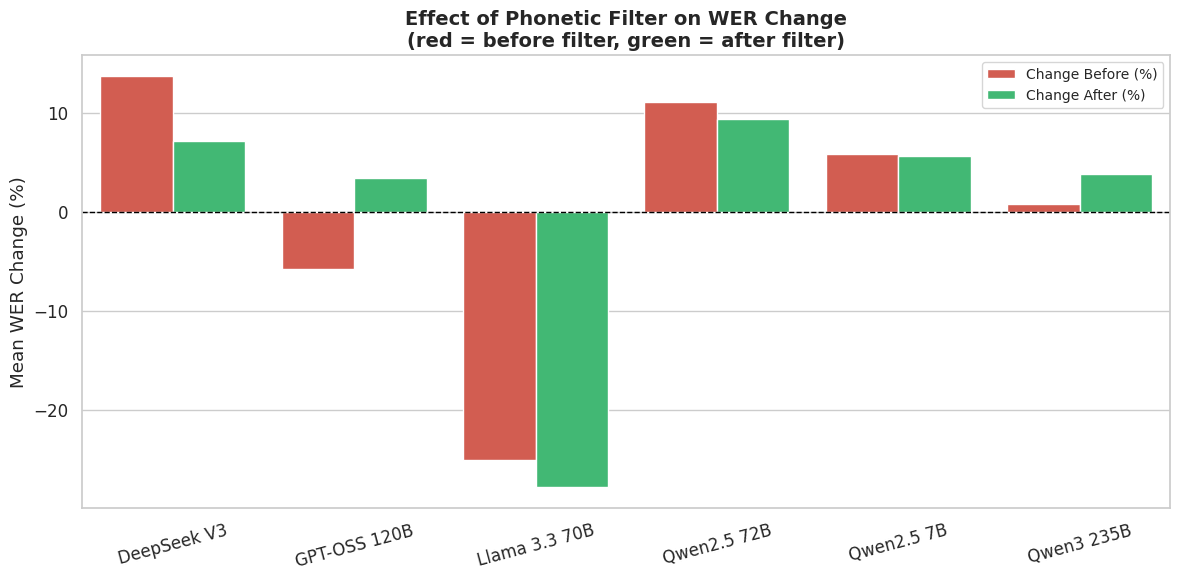

In [ ]:
# график 1B: средний WER Change до и после фильтра по LLM

llm_compare = (
    compare_df
    .groupby('LLM')[[
        'Change Before (%)', 'Change After (%)',
    ]]
    .mean()
    .reset_index()
)

llm_melt = llm_compare.melt(
    id_vars='LLM',
    var_name='Stage',
    value_name='Mean WER Change (%)',
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=llm_melt,
    x='LLM',
    y='Mean WER Change (%)',
    hue='Stage',
    ax=ax,
    palette=['#e74c3c', '#2ecc71'],
    edgecolor='white',
)
ax.axhline(y=0, color='black', ls='--', lw=1)
ax.set_title(
    'Effect of Phonetic Filter on WER Change\n'
    '(red = before filter, green = after filter)',
    fontsize=14, fontweight='bold',
)
ax.set_xlabel('')
ax.set_ylabel('Mean WER Change (%)')
ax.legend(fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

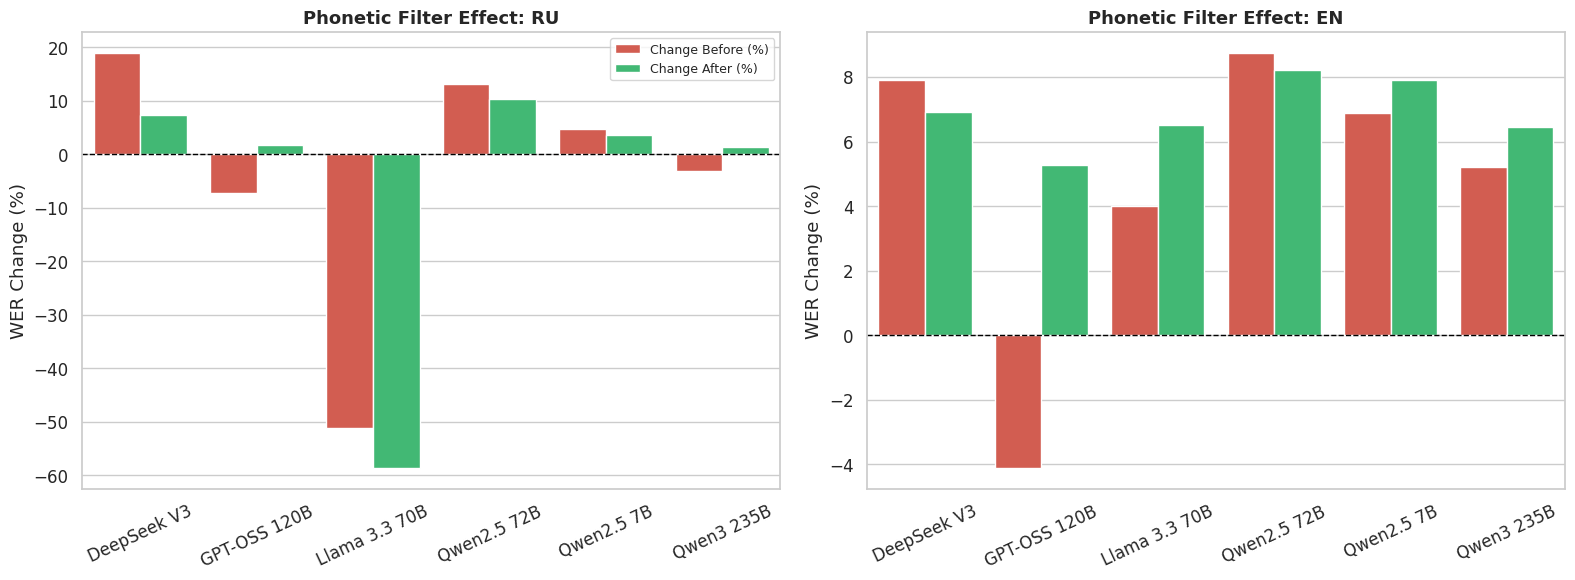

In [ ]:
# график 2B: эффект фильтра по языкам

lang_compare = (
    compare_df
    .groupby(['LLM', 'Language'])[[
        'Change Before (%)', 'Change After (%)',
    ]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, lang in enumerate(['ru', 'en']):
    ax = axes[idx]
    lang_data = lang_compare[
        lang_compare['Language'] == lang
    ]
    lang_melt = lang_data.melt(
        id_vars='LLM',
        value_vars=[
            'Change Before (%)', 'Change After (%)',
        ],
        var_name='Stage',
        value_name='WER Change (%)',
    )
    sns.barplot(
        data=lang_melt,
        x='LLM',
        y='WER Change (%)',
        hue='Stage',
        ax=ax,
        palette=['#e74c3c', '#2ecc71'],
        edgecolor='white',
    )
    ax.axhline(y=0, color='black', ls='--', lw=1)
    ax.set_title(
        f'Phonetic Filter Effect: {lang.upper()}',
        fontsize=13, fontweight='bold',
    )
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    if idx == 0:
        ax.legend(fontsize=9)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

In [ ]:
# примеры: как фильтр откатывает плохие замены

example_keys = [
    k for k in filtered_results_v2
    if 'Llama' in k and 'sova' in k and 'whisper_base' in k
]
if not example_keys:
    example_keys = list(filtered_results_v2.keys())[:1]

for key in example_keys[:1]:
    df = filtered_results_v2[key]
    print(f'\n{"=" * 60}')
    print(f'Experiment: {key}')
    print(f'{"=" * 60}')
    for _, row in df.head(3).iterrows():
        print(f'\nREF: "{row["reference"][:80]}"')
        print(f'ASR: "{row["asr_output"][:80]}"')
        print(f'LLM: "{row["llm_corrected"][:80]}"')
        print(f'FLT: "{row["llm_filtered"][:80]}"')
        print(
            f'WER: baseline={row["wer_baseline"]:.2%}'
            f' -> corrected={row["wer_corrected"]:.2%}'
            f' -> filtered={row["wer_filtered"]:.2%}'
        )


Experiment: Llama 3.3 70B__whisper_base__sova_audiobooks_ru

REF: "надменно глядя по сторонам он величественно прошёл через двор в окружении собак"
ASR: "Нагменно, глядя по сторонам, он величистое напрошел через двор в окружении собак"
LLM: "Наглядя, глядя по сторонам, он величественное напролом прошел через двор в окруж"
FLT: "нагменно глядя по сторонам он величественное величистое прошел через двор в окру"
WER: baseline=25.00% -> corrected=33.33% -> filtered=33.33%

REF: "поезд вагон за вагоном проходит мимо него и он видит в последнем окне последнего"
ASR: "Поезд в Агонзовагоном проходит мимо него и он видит в последний мак мне последне"
LLM: "Поезд в Агонзовагоне проходит мимо него и он видит в последний момент мне послед"
FLT: "поезд в агонзовагоне проходит мимо него и он видит в последний мак мне последнег"
WER: baseline=43.48% -> corrected=43.48% -> filtered=43.48%

REF: "а у тебя все по полу разбросано спорю я"
ASR: "палочянщ Attention to Universe persons Спbildung"
LLM: "пало

### Выводы по фонетической фильтрации (Идея B)

**1. Фильтр принимает 68.5% замен и откатывает 31.5%.**
Из 1738 substitutions 1190 прошли порог Левенштейна (0.5) и были приняты. 548 замен откачены к исходному слову. Дополнительно откачены 614 deletions (слова, удалённые LLM).

**2. Наибольший эффект - на нестабильных моделях.**
GPT-OSS 120B x Wav2Vec2 EN x LS-clean: фильтр улучшает WER Change с -47.4% до +14.5% (дельта +61.8 п.п.). Qwen3 235B x GigaAM CTC x FLEURS RU: с -34.8% до +1.2% (дельта +36.0 п.п.). Фильтр преобразует вредные модели в нейтральные или полезные.

**3. Фильтр вредит лучшим коррекциям DeepSeek V3.**
На GigaAM RNNT x FLEURS RU фильтр снижает WER Change с +35.5% до +8.5% (дельта -27.0 п.п.). Причина: DeepSeek делает качественные замены, фонетически далёкие от оригинала. Фильтр откатывает их, поскольку расстояние Левенштейна превышает порог.

**4. Компромисс фильтрации.**
Порог 0.5 выбран как баланс между защитой от галлюцинаций и сохранением качественных коррекций. Оптимизация порога на валидационном подмножестве - направление дальнейшей работы.

In [ ]:
# загрузка результатов БЕЗ confidence-aware из копии

import pickle

with open('/content/all_results_v2_no_conf.pkl', 'rb') as f:
    all_results_no_conf = pickle.load(f)

print(f'Loaded {len(all_results_no_conf)} results (no confidence)')

Loaded 114 results (no confidence)


In [ ]:
# загрузка filtered без confidence
with open('/content/filtered_no_conf.pkl', 'rb') as f:
    filtered_no_conf = pickle.load(f)

print(f'Loaded {len(filtered_no_conf)} filtered results (no confidence)')

Loaded 114 filtered results (no confidence)


## Абляционное исследование (Ablation Study)

Оценка вклада каждого компонента двухкомпонентного метода:
- **Baseline** - результат ASR без коррекции
- **LLM (без confidence)** - результат простой коррекции
- **+ Confidence-aware LLM** - коррекция только низкоуверенных фрагментов (Whisper: threshold=-0.35, GigaAM/Wav2Vec2: все фрагменты)
- **+ Confidence-aware LLM + фонетический фильтр** - полный метод

In [ ]:
# Ablation study: 5 уровней
# A: Baseline
# B: +LLM (no confidence, no filter) - из копии
# C: +LLM+Filter (no confidence, with filter) - из копии
# D: + Confidence-aware LLM (confidence, no filter) - текущий прогон
# E: + Confidence-aware LLM + фонетический фильтр (confidence + filter)

ablation_rows = []

for key, df in filtered_results_v2.items():
    if len(df) == 0:
        continue
    parts = key.split('__')
    if len(parts) != 3:
        continue
    llm_name = parts[0]
    asr_meta = asr_registry.get(parts[1], {})
    ds_meta = datasets_registry.get(parts[2], {})

    bl_wer = df['wer_baseline'].mean()

    # B: +LLM (no confidence, no filter)
    noconf_df = all_results_no_conf.get(key, pd.DataFrame())
    b_wer = (
        noconf_df['wer_corrected'].mean()
        if len(noconf_df) > 0 else bl_wer
    )

    # C: +LLM+Filter (no confidence, with filter)
    filt_noconf_df = filtered_no_conf.get(key, pd.DataFrame())
    c_wer = (
        filt_noconf_df['wer_filtered'].mean()
        if len(filt_noconf_df) > 0 else bl_wer
    )

    # D: +Conf-LLM (confidence, no filter)
    conf_df = all_results_v2.get(key, pd.DataFrame())
    d_wer = (
        conf_df['wer_corrected'].mean()
        if len(conf_df) > 0 else bl_wer
    )

    # E: +Conf-LLM+Filter (confidence + filter)
    e_wer = df['wer_filtered'].mean()

    ablation_rows.append({
        'LLM': llm_name,
        'ASR': asr_meta.get('display_name', parts[1]),
        'Dataset': ds_meta.get('display_name', parts[2]),
        'Language': ds_meta.get('language', '?'),
        'A: Baseline': bl_wer,
        'Delta B: +LLM': (bl_wer - b_wer) / bl_wer * 100,
        'Delta C: +LLM+Filt': (bl_wer - c_wer) / bl_wer * 100,
        'Delta D: +Conf': (bl_wer - d_wer) / bl_wer * 100,
        'Delta E: Full': (bl_wer - e_wer) / bl_wer * 100,
    })

ablation_df = pd.DataFrame(ablation_rows)

abl_summary = (
    ablation_df
    .groupby('LLM')[[
        'Delta B: +LLM', 'Delta C: +LLM+Filt',
        'Delta D: +Conf', 'Delta E: Full',
    ]]
    .mean()
    .round(2)
    .reset_index()
)
print('Ablation Summary (mean WER Change %):')
print(abl_summary.to_string(index=False))

Ablation Summary (mean WER Change %):
          LLM  Delta B: +LLM  Delta C: +LLM+Filt  Delta D: +Conf  Delta E: Full
  DeepSeek V3          19.91               13.95           13.74           7.18
 GPT-OSS 120B         -15.95               -1.14           -5.74           3.44
Llama 3.3 70B         -34.72              -35.34          -25.07         -27.81
  Qwen2.5 72B          12.82               10.93           11.04           9.31
   Qwen2.5 7B           0.12                4.88            5.79           5.64
   Qwen3 235B          -5.93                4.28            0.77           3.81


In [ ]:
# Ablation по языку (5 уровней)

abl_lang = (
    ablation_df
    .groupby(['LLM', 'Language'])[[
        'Delta B: +LLM', 'Delta C: +LLM+Filt',
        'Delta D: +Conf', 'Delta E: Full',
    ]]
    .mean()
    .round(2)
    .reset_index()
)
print('Ablation by Language:')
print(abl_lang.to_string(index=False))

Ablation by Language:
          LLM Language  Delta B: +LLM  Delta C: +LLM+Filt  Delta D: +Conf  Delta E: Full
  DeepSeek V3       en          19.00               16.56            7.91           6.91
  DeepSeek V3       ru          20.74               11.60           18.99           7.42
 GPT-OSS 120B       en         -22.97               -0.20           -4.12           5.27
 GPT-OSS 120B       ru          -9.63               -1.98           -7.19           1.79
Llama 3.3 70B       en          -6.46                0.88            4.00           6.52
Llama 3.3 70B       ru         -60.15              -67.94          -51.23         -58.71
  Qwen2.5 72B       en           6.84                6.80            8.75           8.20
  Qwen2.5 72B       ru          18.20               14.64           13.09          10.30
   Qwen2.5 7B       en          -3.34                5.56            6.89           7.91
   Qwen2.5 7B       ru           3.23                4.27            4.80           3.59

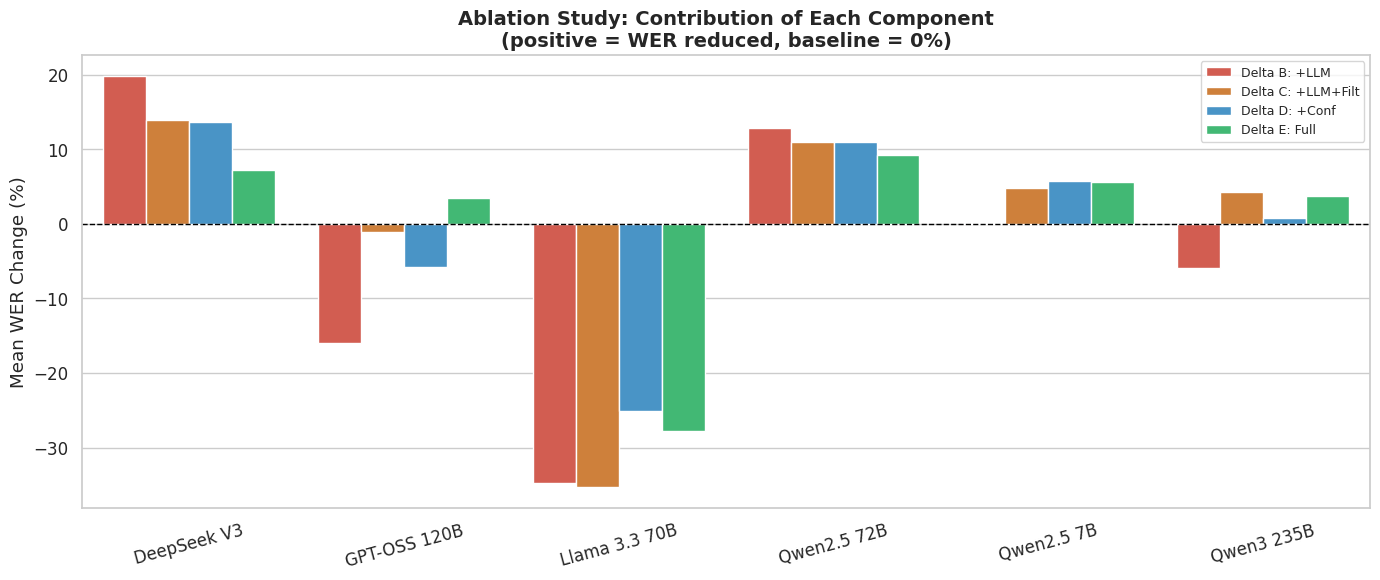

In [ ]:
# график Ablation (5 уровней)

abl_plot = abl_summary.melt(
    id_vars='LLM',
    var_name='Method',
    value_name='Mean WER Change (%)',
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=abl_plot,
    x='LLM',
    y='Mean WER Change (%)',
    hue='Method',
    ax=ax,
    palette=['#e74c3c', '#e67e22', '#3498db', '#2ecc71'],
    edgecolor='white',
)
ax.axhline(y=0, color='black', ls='--', lw=1)
ax.set_title(
    'Ablation Study: Contribution of Each Component\n'
    '(positive = WER reduced, baseline = 0%)',
    fontsize=14, fontweight='bold',
)
ax.set_xlabel('')
ax.set_ylabel('Mean WER Change (%)')
ax.legend(fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# Ablation по типу ASR (5 уровней)

def get_asr_type(asr_name):
    if 'Whisper' in asr_name:
        return 'Encoder-Decoder (Whisper)'
    elif 'CTC' in asr_name or 'Wav2Vec2' in asr_name:
        return 'CTC (GigaAM CTC, Wav2Vec2)'
    elif 'RNNT' in asr_name:
        return 'RNNT (GigaAM RNNT)'
    return 'Other'

ablation_df['ASR Type'] = ablation_df['ASR'].apply(
    get_asr_type,
)

abl_asr = (
    ablation_df
    .groupby('ASR Type')[[
        'Delta B: +LLM', 'Delta C: +LLM+Filt',
        'Delta D: +Conf', 'Delta E: Full',
    ]]
    .mean()
    .round(2)
    .reset_index()
)
print('Ablation by ASR Type:')
print(abl_asr.to_string(index=False))

Ablation by ASR Type:
                  ASR Type  Delta B: +LLM  Delta C: +LLM+Filt  Delta D: +Conf  Delta E: Full
CTC (GigaAM CTC, Wav2Vec2)           8.01               10.60            7.19           9.84
 Encoder-Decoder (Whisper)         -13.50               -7.50           -5.52          -5.70
        RNNT (GigaAM RNNT)           1.85               -3.49            3.28          -3.46


### Выводы абляционного исследования

Абляционное исследование проводилось на 5 уровнях: A (baseline), B (+LLM), C (+LLM+фильтр), D (+confidence-aware LLM), E (полный метод: confidence-aware + фильтр). Результаты прогонов B и D получены в разных сессиях; для моделей без confidence (GigaAM, Wav2Vec2) значения B и D могут незначительно различаться вследствие стохастической природы генерации языковых моделей, работы API.

**1. Каждый компонент вносит независимый вклад.** Фонетический фильтр (B -> C) превращает GPT-OSS из -15,95% в -1,14% (+14,81 п.п.) и Qwen3 из -5,93% в +4,28% (+10,21 п.п.). Confidence-aware (B -> D) превращает GPT-OSS из -15,95% в -5,74% (+10,21 п.п.) и Qwen3 из -5,93% в +0,77% (+6,70 п.п.). Полный метод (E) даёт лучший результат для проблемных моделей: GPT-OSS +3,44%, Qwen3 +3,81%.

**2. Фонетический фильтр наиболее эффективен для английского языка.** На EN фильтр (B -> C) улучшает GPT-OSS с -22,97% до -0,20% (+22,77 п.п.), Llama с -6,46% до +0,88% (+7,34 п.п.), Qwen 7B с -3,34% до +5,56% (+8,90 п.п.). На RU эффект менее выражен из-за аномалии Llama на SOVA.

**3. Confidence-aware наиболее эффективен для Whisper.** По типу ASR: Encoder-Decoder (Whisper) улучшается с -13,50% (B) до -5,52% (D), то есть на 7,98 п.п. Для CTC разница между B (+8,01%) и D (+7,19%) составляет лишь 0,82 п.п. - в пределах стохастической вариативности.

**4. CTC-модели получают наибольший выигрыш от фильтра.** CTC: B +8,01% -> C +10,60% (+2,59 п.п.). Полный метод (E) для CTC даёт +9,84% - лучший результат среди всех типов ASR.

**5. Для сильных LLM метод действует консервативно.** DeepSeek V3: B +19,91% -> E +7,18%. Qwen2.5 72B: B +12,82% -> E +9,31%. Метод жертвует частью выигрыша сильных моделей ради стабильности слабых.



## Выводы


Данный раздел содержит результаты confidence-aware прогона (порог confidence = -0.35) и полного абляционного исследования (5 уровней).

### Baseline WER по моделям и датасетам (30 сэмплов)

| ASR | Dataset | Language | Baseline WER |
|-----|---------|----------|-------------|
| Whisper base | LibriSpeech test-clean | EN | 3.78% |
| Whisper base | LibriSpeech test-other | EN | 10.41% |
| Whisper base | FLEURS English | EN | 16.18% |
| Whisper base | FLEURS Russian | RU | 25.68% |
| Whisper base | SOVA audiobooks | RU | 38.06% |
| Whisper medium | LibriSpeech test-clean | EN | 2.81% |
| Whisper medium | LibriSpeech test-other | EN | 6.19% |
| Whisper medium | FLEURS English | EN | 6.29% |
| Whisper medium | FLEURS Russian | RU | 11.48% |
| Whisper medium | SOVA audiobooks | RU | 17.63% |
| GigaAM v2 CTC | FLEURS Russian | RU | 12.46% |
| GigaAM v2 CTC | SOVA audiobooks | RU | 7.06% |
| GigaAM v2 RNNT | FLEURS Russian | RU | 12.06% |
| GigaAM v2 RNNT | SOVA audiobooks | RU | 6.57% |
| Wav2Vec2 XLS-R 1B | FLEURS Russian | RU | 19.03% |
| Wav2Vec2 XLS-R 1B | SOVA audiobooks | RU | 20.96% |
| Wav2Vec2 XLS-R 1B EN | LibriSpeech test-clean | EN | 6.13% |
| Wav2Vec2 XLS-R 1B EN | LibriSpeech test-other | EN | 6.03% |
| Wav2Vec2 XLS-R 1B EN | FLEURS English | EN | 15.75% |

### Confidence-aware: статистика пропусков (Whisper)

| Эксперимент | Пропущено | Всего | % пропуска |
|---|---|---|---|
| WB x LS-clean | 13 | 14 | 92.9% |
| WB x LS-other | 12 | 20 | 60.0% |
| WB x FLEURS EN | 11 | 24 | 45.8% |
| WB x FLEURS RU | 14 | 29 | 48.3% |
| WB x SOVA | 2 | 25 | 8.0% |
| WM x LS-clean | 10 | 10 | 100.0% |
| WM x LS-other | 11 | 15 | 73.3% |
| WM x FLEURS EN | 20 | 21 | 95.2% |
| WM x FLEURS RU | 22 | 24 | 91.7% |
| WM x SOVA | 17 | 22 | 77.3% |

### Ablation study (5 уровней)

| LLM | B: +LLM | C: +LLM+Filt | D: +Conf | E: Full |
|-----|---------|--------------|----------|---------|
| DeepSeek V3 | +19.91 | +13.95 | +13.74 | +7.18 |
| GPT-OSS 120B | -15.95 | -1.14 | -5.74 | +3.44 |
| Llama 3.3 70B | -34.72 | -35.34 | -25.07 | -27.81 |
| Qwen2.5 72B | +12.82 | +10.93 | +11.04 | +9.31 |
| Qwen2.5 7B | +0.12 | +4.88 | +5.79 | +5.64 |
| Qwen3 235B | -5.93 | +4.28 | +0.77 | +3.81 |

Примечание для таблички по типам ASR: результаты B и D получены в разных сессиях. Для моделей без confidence (GigaAM, Wav2Vec2) значения могут незначительно различаться вследствие стохастической природы генерации языковых моделей.

### Ключевые наблюдения

**1. Confidence-aware предотвращает ухудшение на точных транскрипциях.**
Whisper medium x LS-clean (baseline WER 2.81%): 100% сэмплов пропущены. Без confidence-aware LLM ухудшала WER на 3.9-102.2%. С confidence-aware: 0.0% изменение для всех 6 LLM.

**2. Каждый компонент метода вносит независимый вклад.**
Фонетический фильтр (B -> C) превращает GPT-OSS из -15.95% в -1.14%. Confidence-aware (B -> D) превращает GPT-OSS из -15.95% в -5.74%. Полный метод (E) даёт лучший результат: GPT-OSS +3.44%.

**3. Метод превращает вредные LLM в полезные.**
GPT-OSS: B -15.95% -> E +3.44%. Qwen3: B -5.93% -> E +3.81%. Qwen 7B: B +0.12% -> E +5.64%.

**4. DeepSeek V3 - лучшая модель, но метод действует консервативно.**
B +19.91% -> E +7.18%. Компромисс: стабильность слабых моделей за счёт части выигрыша сильных.

**5. CTC-модели лучше всего поддаются полному методу.**
CTC: B +8.01% -> C +10.60% -> E +9.84%. Encoder-Decoder (Whisper): B -13.50% -> D -5.52% -> E -5.70%.

**6. Корреляция confidence и WER: -0.619.**
Порог -0.35 пропускает 70.7% Whisper-сэмплов (средний WER 7.8%) и корректирует 29.3% (средний WER 28.5%).
